Maps - Event Locations

pygmt-session [WARNING]: Remote dataset given to a data processing module but no registration was specified - default to gridline registration (if available)


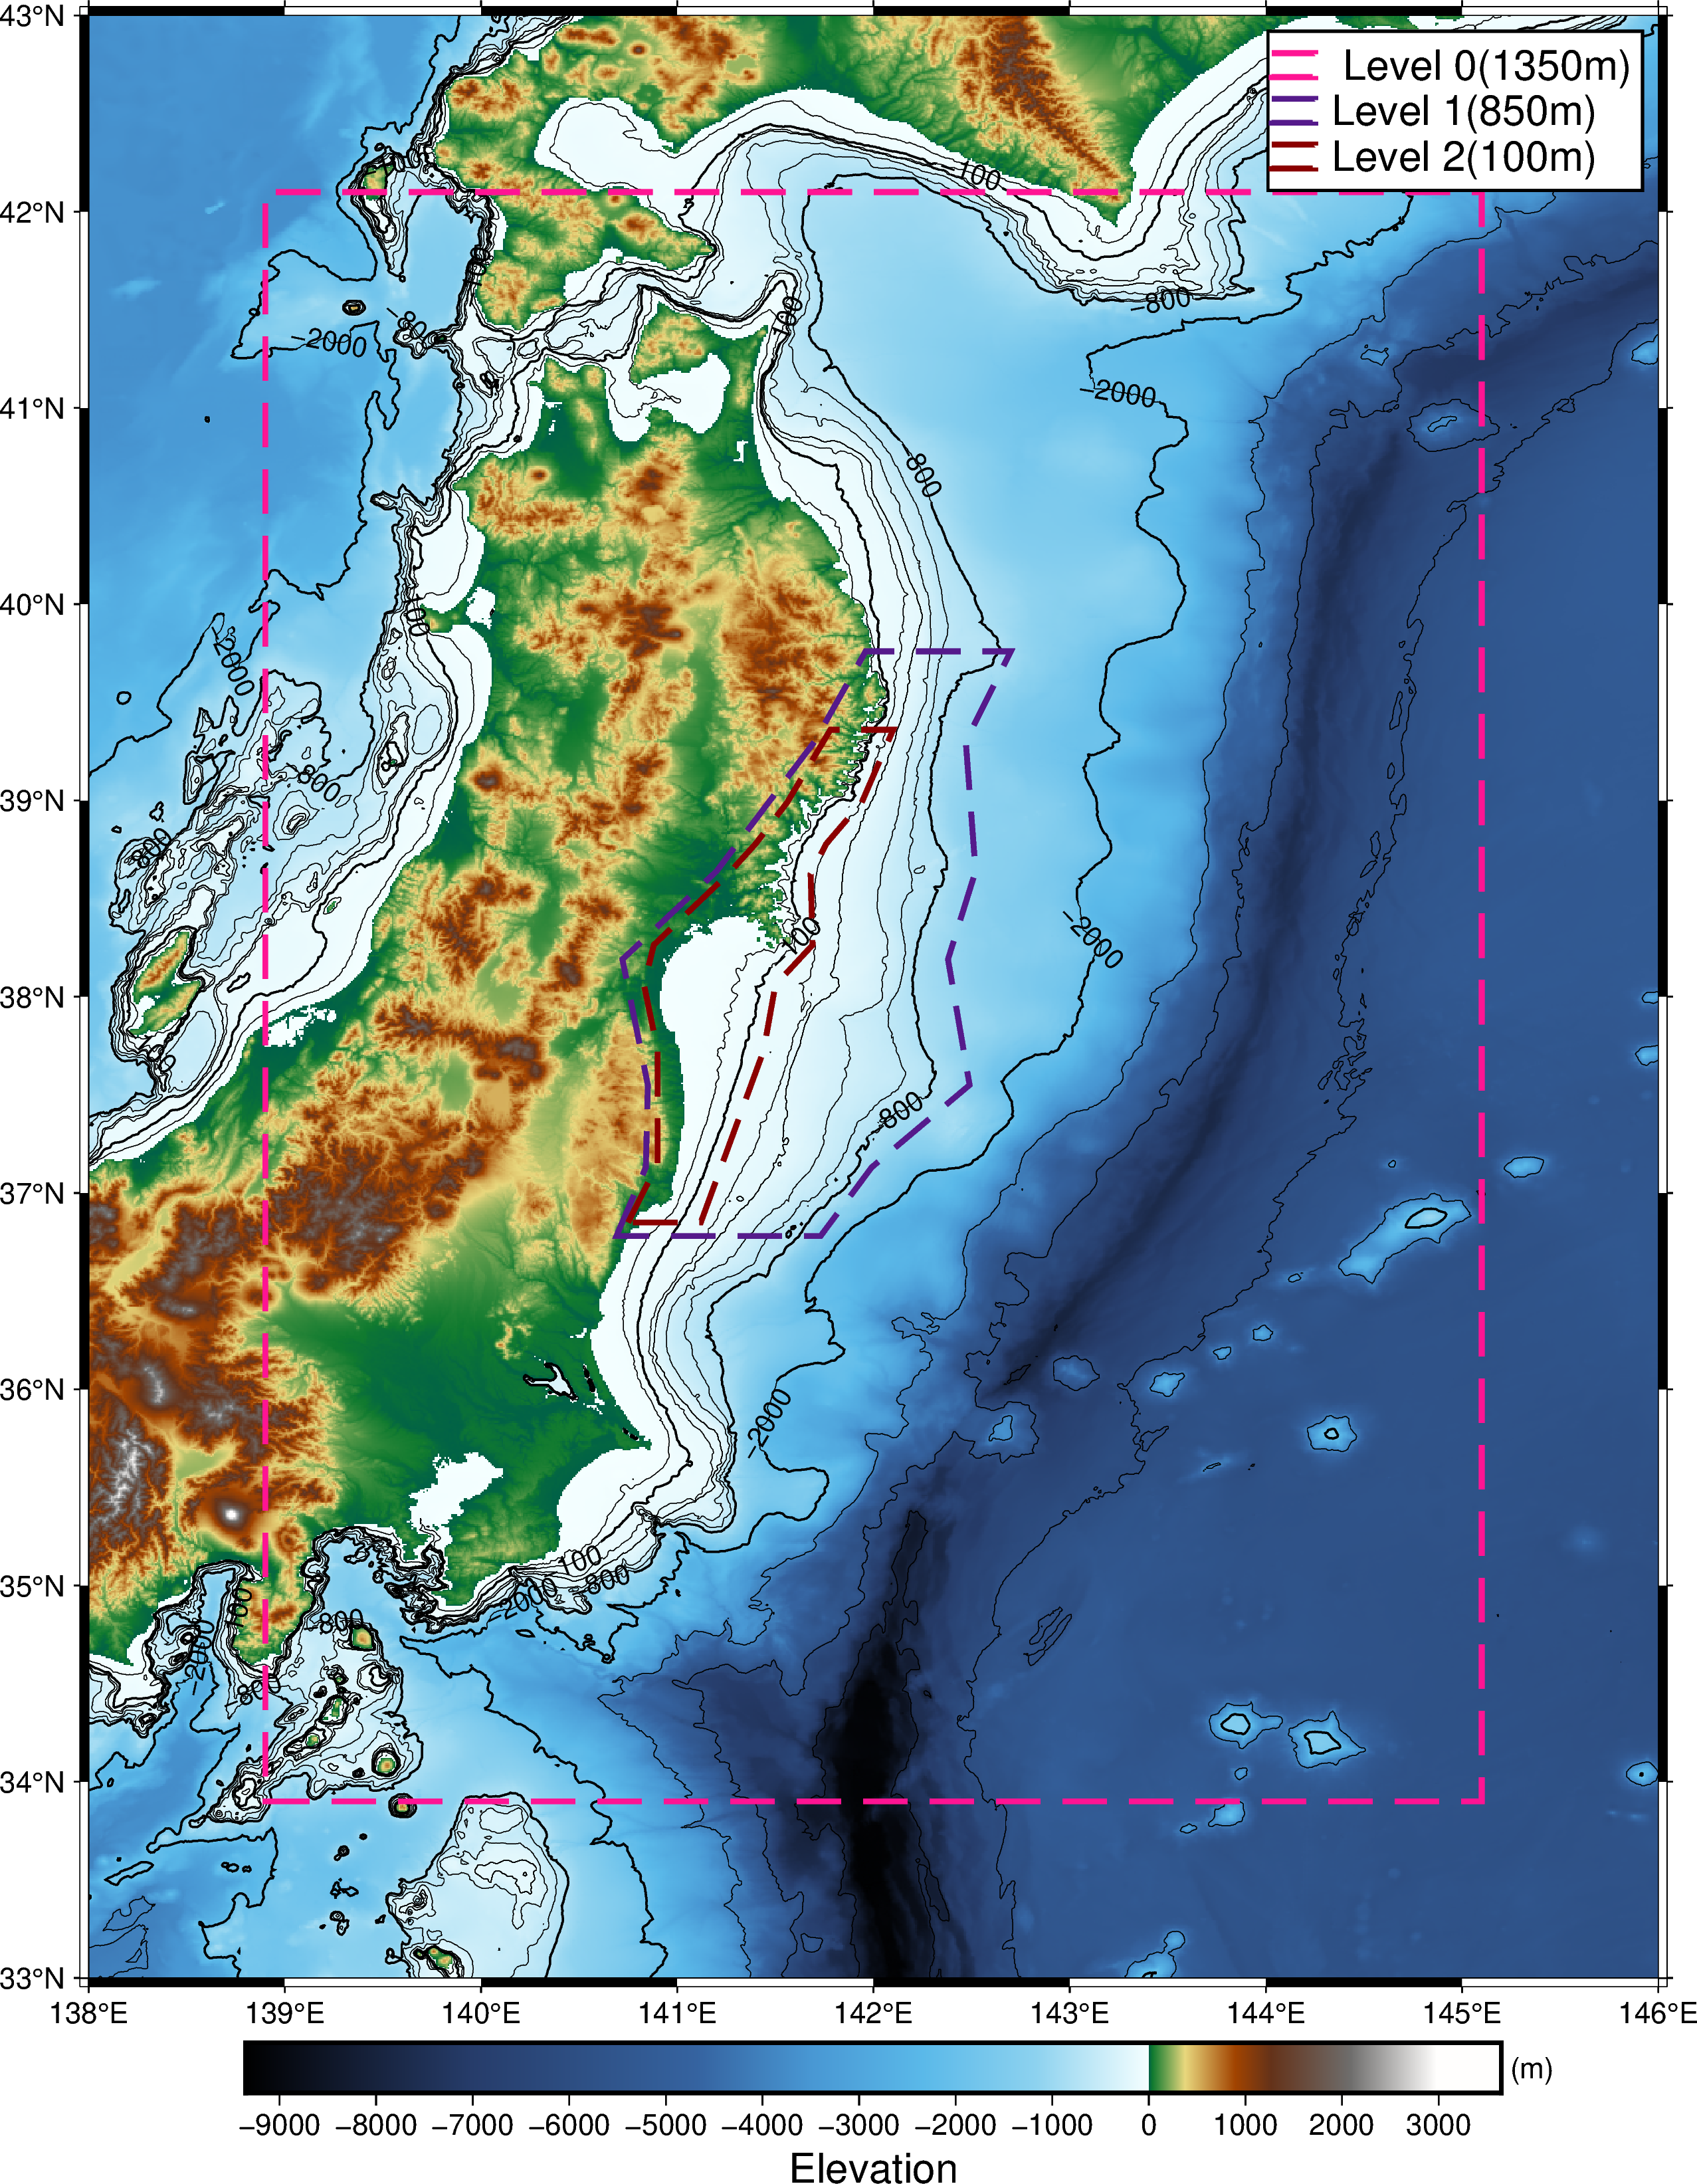

In [3]:
import geopandas as gpd
import numpy as np
import pygmt
import pandas as pd

# Load the elevation grid
grid = pygmt.datasets.load_earth_relief(resolution="30s",region=[138,146,33,43])
#geoclaw model domain extent
domain = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/geoclaw/domain.gpkg")
Level0 = domain[domain.Name == '1350']
Level1 = domain[domain.Name == '850']
Level2 = domain[domain.Name == '100']

#source
siftpoints = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/GEM/siftpoints.shp")
slabpoints = pd.read_csv("/mnt/data/nragu/Tsunami/Tohoku/gis/GEM/sourceparameters.csv")
gauges =pd.read_csv("/mnt/data/nragu/Tsunami/Tohoku/gis/2011/Formatted/ObservationLocationInfo.csv")
codelist = [205,801,802,803,804,806]
sel_gauges = gauges[gauges.Code.isin(codelist)]

#plot them
fig = pygmt.Figure()
fig.grdimage(grid=grid, projection="x2.5c/2.5c", frame="a", cmap="geo")
fig.grdcontour(grid=grid, interval=2000,limit=[-10000, -2000])#,annotation="2000+f9p,black")
fig.grdcontour(grid=grid, interval=200,limit=[-800, -200])#,annotation="200+f9p,black")
fig.grdcontour(grid=grid, interval=50,limit=[-200, -50])#,annotation="50+f9p,black")
fig.grdcontour(grid=grid, interval=2000,limit=[-2001, -1999],annotation="2000+f10p,black")
fig.grdcontour(grid=grid, interval=800,limit=[-801, -799],annotation="800+f10p,black")
fig.grdcontour(grid=grid, interval=100,limit=[-101, -99],annotation="100+f10p,black")

# fig.plot(data=siftpoints, style="c0.25c", color="red", pen="red", label="bottom centre of fault(type 2)")
# fig.plot(
#     x=slabpoints['lon'],
#     y=slabpoints['lat'],
#     style="c0.15c",
#     color="orange",
#     pen="orange",
#     label="top centre of fault(type 1) ",
# )

#add point and annotations for gauges
# fig.plot(
#     x=sel_gauges.Longitude,
#     y=sel_gauges.Latitude,
#     style="t0.5c",
#     color="Green",
#     pen="Green",
#     label="Tsunami Gauge",
# )

# for i in range(len(sel_gauges)):
#     fig.text(
#         x=sel_gauges['Longitude'].iloc[i],
#         y=sel_gauges['Latitude'].iloc[i],
#         text=sel_gauges['Code'].iloc[i],
#         font="14p,Helvetica-Bold,black",
#         justify="CM",
#         offset="0.5c/0.4c",
#     )

fig.plot(data=Level0, pen="2p,deeppink1,-", close=True,label=" Level 0(1350m)")
fig.plot(data=Level1, pen="2p,purple4,-", close=True,label="Level 1(850m)")
fig.plot(data=Level2, pen="2p,red4,-", close=True,label="Level 2(100m)")
fig.colorbar(frame=["1000", "x+lElevation", "y+l(m)"])
with pygmt.config(FONT_ANNOT_PRIMARY="15p"):
    fig.legend()
# fig.savefig("_plot/model_region_geoclaw.png")
fig.show()


Fault Locations

pygmt-session [WARNING]: Remote dataset given to a data processing module but no registration was specified - default to gridline registration (if available)


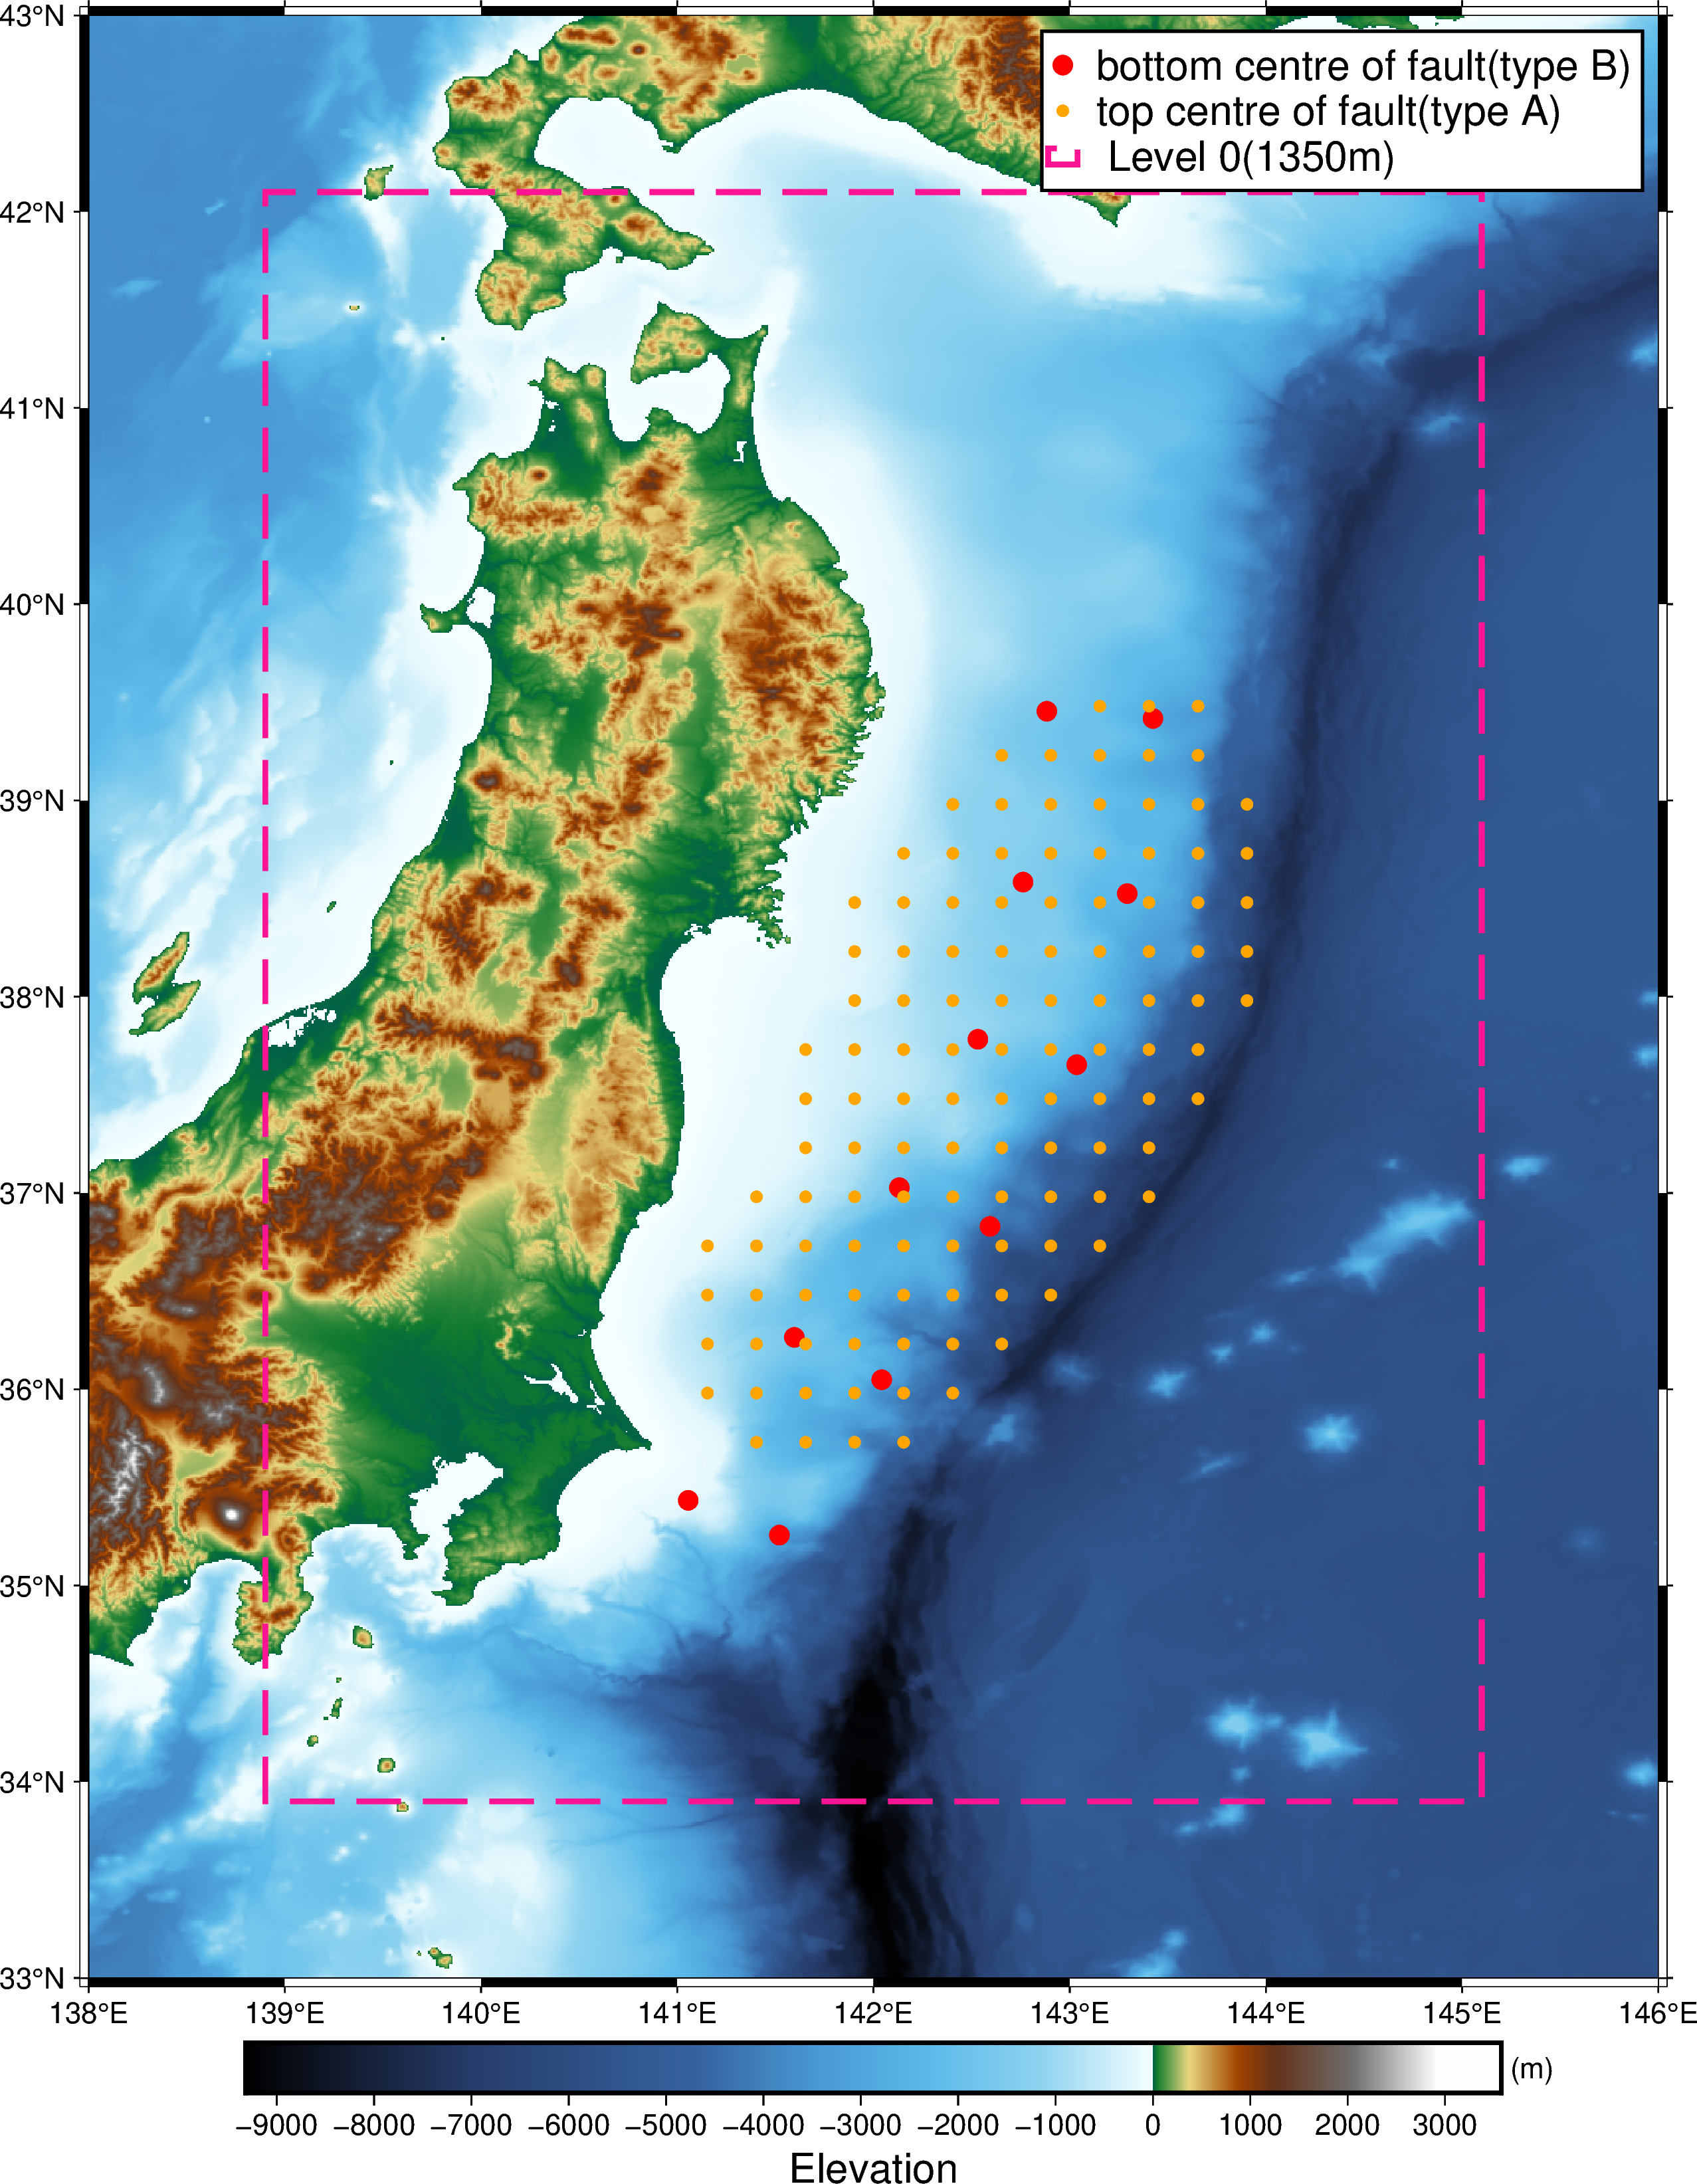

In [2]:
import geopandas as gpd
import numpy as np
import pygmt
import pandas as pd

# Load the elevation grid
grid = pygmt.datasets.load_earth_relief(resolution="30s",region=[138,146,33,43])
#geoclaw model domain extent
domain = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/geoclaw/domain.gpkg")
Level0 = domain[domain.Name == '1350']
Level1 = domain[domain.Name == '850']
Level2 = domain[domain.Name == '100']

#source
siftpoints = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/GEM/siftpoints.shp")
slabpoints = pd.read_csv("/mnt/data/nragu/Tsunami/Tohoku/gis/GEM/sourceparameters.csv")
gauges =pd.read_csv("/mnt/data/nragu/Tsunami/Tohoku/gis/2011/Formatted/ObservationLocationInfo.csv")
codelist = [205,801,802,803,804,806]
sel_gauges = gauges[gauges.Code.isin(codelist)]

#plot them
fig = pygmt.Figure()
fig.grdimage(grid=grid, projection="x2.5c/2.5c", frame="a", cmap="geo")
# fig.grdcontour(grid=grid, interval=2000,limit=[-10000, -2000])#,annotation="2000+f9p,black")
# fig.grdcontour(grid=grid, interval=200,limit=[-800, -200])#,annotation="200+f9p,black")
# fig.grdcontour(grid=grid, interval=50,limit=[-200, -50])#,annotation="50+f9p,black")
# fig.grdcontour(grid=grid, interval=2000,limit=[-2001, -1999],annotation="2000+f10p,black")
# fig.grdcontour(grid=grid, interval=800,limit=[-801, -799],annotation="800+f10p,black")
# fig.grdcontour(grid=grid, interval=100,limit=[-101, -99],annotation="100+f10p,black")

fig.plot(data=siftpoints,
         style="c0.25c",
         color="red",
         pen="red",
         label="bottom centre of fault(type B)")

fig.plot(
    x=slabpoints['lon'],
    y=slabpoints['lat'],
    style="c0.15c",
    color="orange",
    pen="orange",
    label="top centre of fault(type A) ",
)

#add point and annotations for gauges
# fig.plot(
#     x=sel_gauges.Longitude,
#     y=sel_gauges.Latitude,
#     style="t0.5c",
#     color="Green",
#     pen="Green",
#     label="Tsunami Gauge",
# )

# for i in range(len(sel_gauges)):
#     fig.text(
#         x=sel_gauges['Longitude'].iloc[i],
#         y=sel_gauges['Latitude'].iloc[i],
#         text=sel_gauges['Code'].iloc[i],
#         font="12p,Helvetica-Bold,black",
#         justify="CM",
#         offset="0.5c/0.4c",
# )

fig.plot(data=Level0, pen="2p,deeppink1,-", close=True,label=" Level 0(1350m)")
# fig.plot(data=Level1, pen="2p,purple4,-", close=True,label="Level 1(850m)")
# fig.plot(data=Level2, pen="2p,red4,-", close=True,label="Level 2(100m)")
fig.colorbar(frame=["1000", "x+lElevation", "y+l(m)"])
with pygmt.config(FONT_ANNOT_PRIMARY="15p"):
    fig.legend()
fig.savefig("_plots/model_region_fault.png")
fig.show()


Initial Displacement Examples

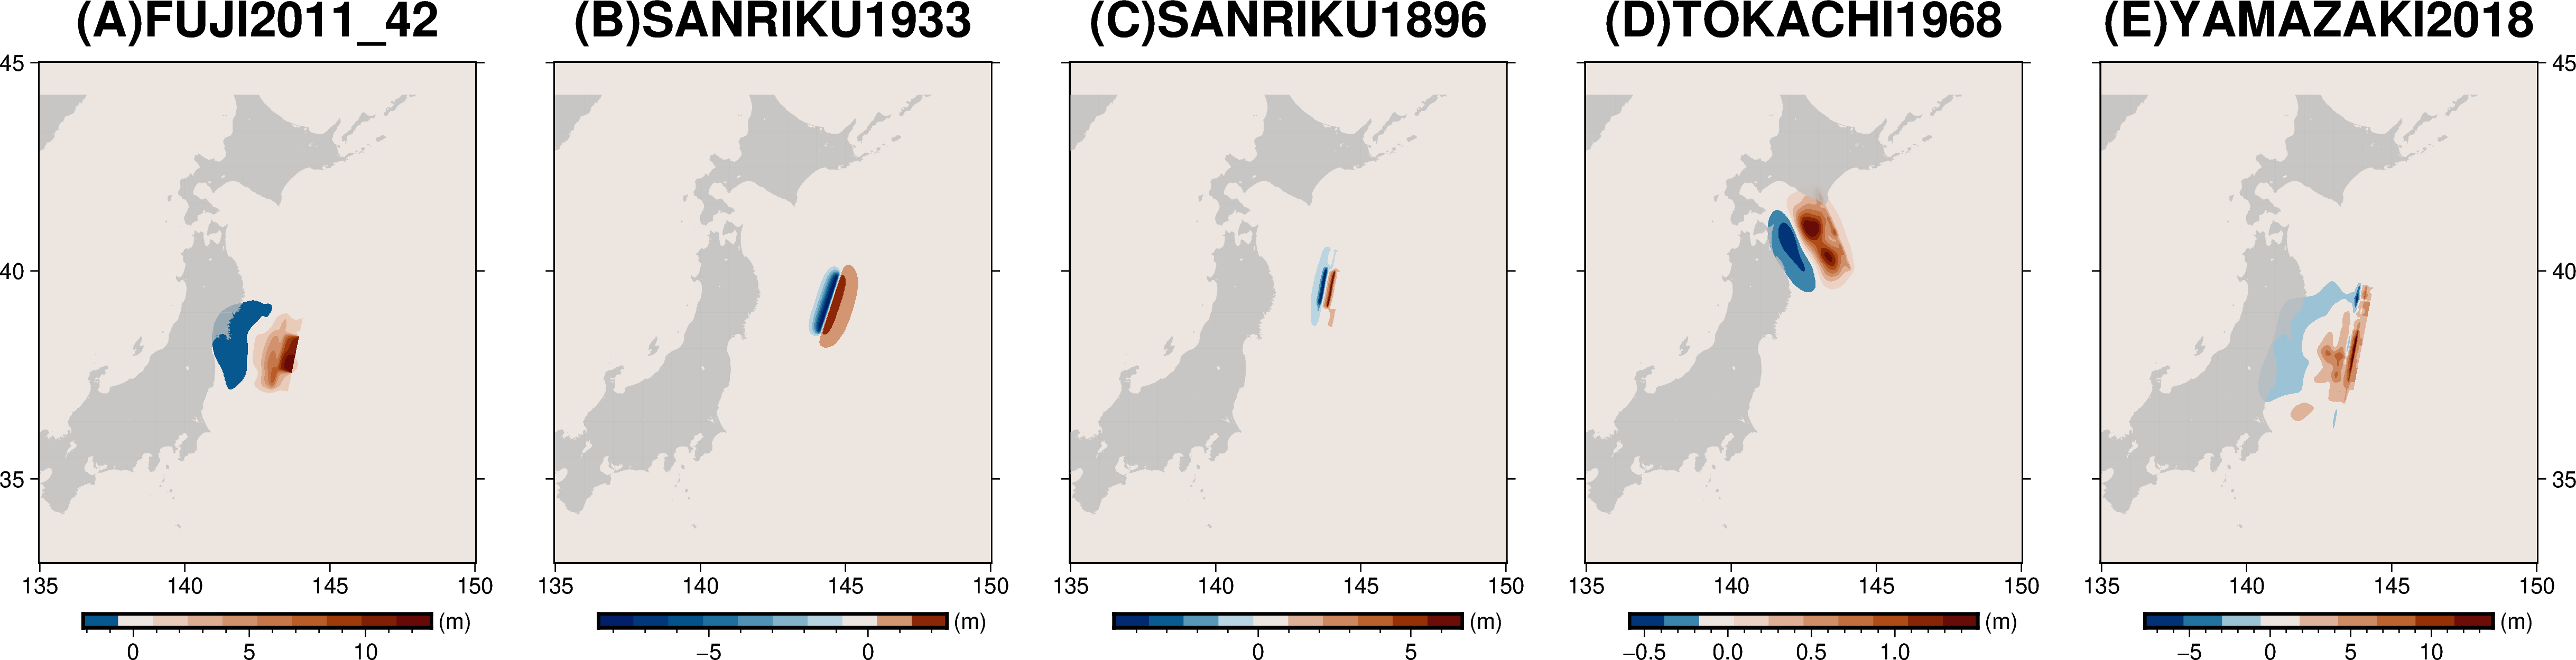

In [6]:
import geopandas as gpd
import numpy as np
import pygmt
import pandas as pd
import os
import rasterio
import xarray as xr

#historic tsunami events
path = '/mnt/data/nragu/Tsunami/Tohoku/gis/dtopo_his/dtopoasc/'

#find files ending with *_2.asc
filelist = [f for f in os.listdir(path) if f.endswith('_2.asc')]
filelist = filelist[0],filelist[2],filelist[3],filelist[4],filelist[1]

#filter file name to remove path and _2.asc
events = [f.replace('_2.asc','') for f in filelist]
events = [f.replace(path,'') for f in events]

#raster processing
xlimits = 135,150
ylimits = 45,30
cellsize = 0.01215

fig = pygmt.Figure()
# Create subplots with shared x and y scales
with fig.subplot(
    nrows=1,
    ncols=5,
    figsize=("40c", "8c"),
    sharey=True,
    # autolabel=True,
    margins=["0.5c", "0.5c"],
    frame = ["af"],
    ):
    alpha = ['A','B','C','D','E']
    for i,f in enumerate(filelist):  
        #read 
        grid = rasterio.open(path + f) #open ascii file
        data = grid.read(1) #read 
        event = events[i]
        if event == 'YAMAZAKI2018_TPMOD_Static':
            event = 'YAMAZAKI2018'

        # Create coordinates for longitude and latitude
        lon = np.linspace(xlimits[0], xlimits[1], data.shape[1])
        lat = np.linspace(ylimits[0], ylimits[1], data.shape[0])

        # Convert to xarray DataArray
        xgrid = xr.DataArray(data, coords=[lat, lon], dims=['lat', 'lon'])
        maxval = xgrid.max().values 
        minval = xgrid.min().values

        #geoclaw model domain extent
        domain = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/geoclaw/domain.gpkg")
        Level0 = domain[domain.Name == '1350']

        # Plot observed data
        with fig.set_panel(panel=[i]):
            pygmt.makecpt(cmap="vik+h0", series=[minval,maxval,(maxval-minval)/10])
            fig.basemap(frame=["a", "+t({}){}".format(alpha[i],event)],region = [135,150,33,45])
            fig.grdimage(grid=xgrid,cmap = True)
            fig.coast(land= "gray",transparency=20)
            # fig.plot(data=Level0, pen="2p,deeppink1,-", close=True)#,label=" Level 0(1350m)")
            fig.colorbar(frame=["x", "y+l(m)"])
            # fig.legend()
fig.savefig("_plots/historic_tsunami_displacement.png")
fig.show()


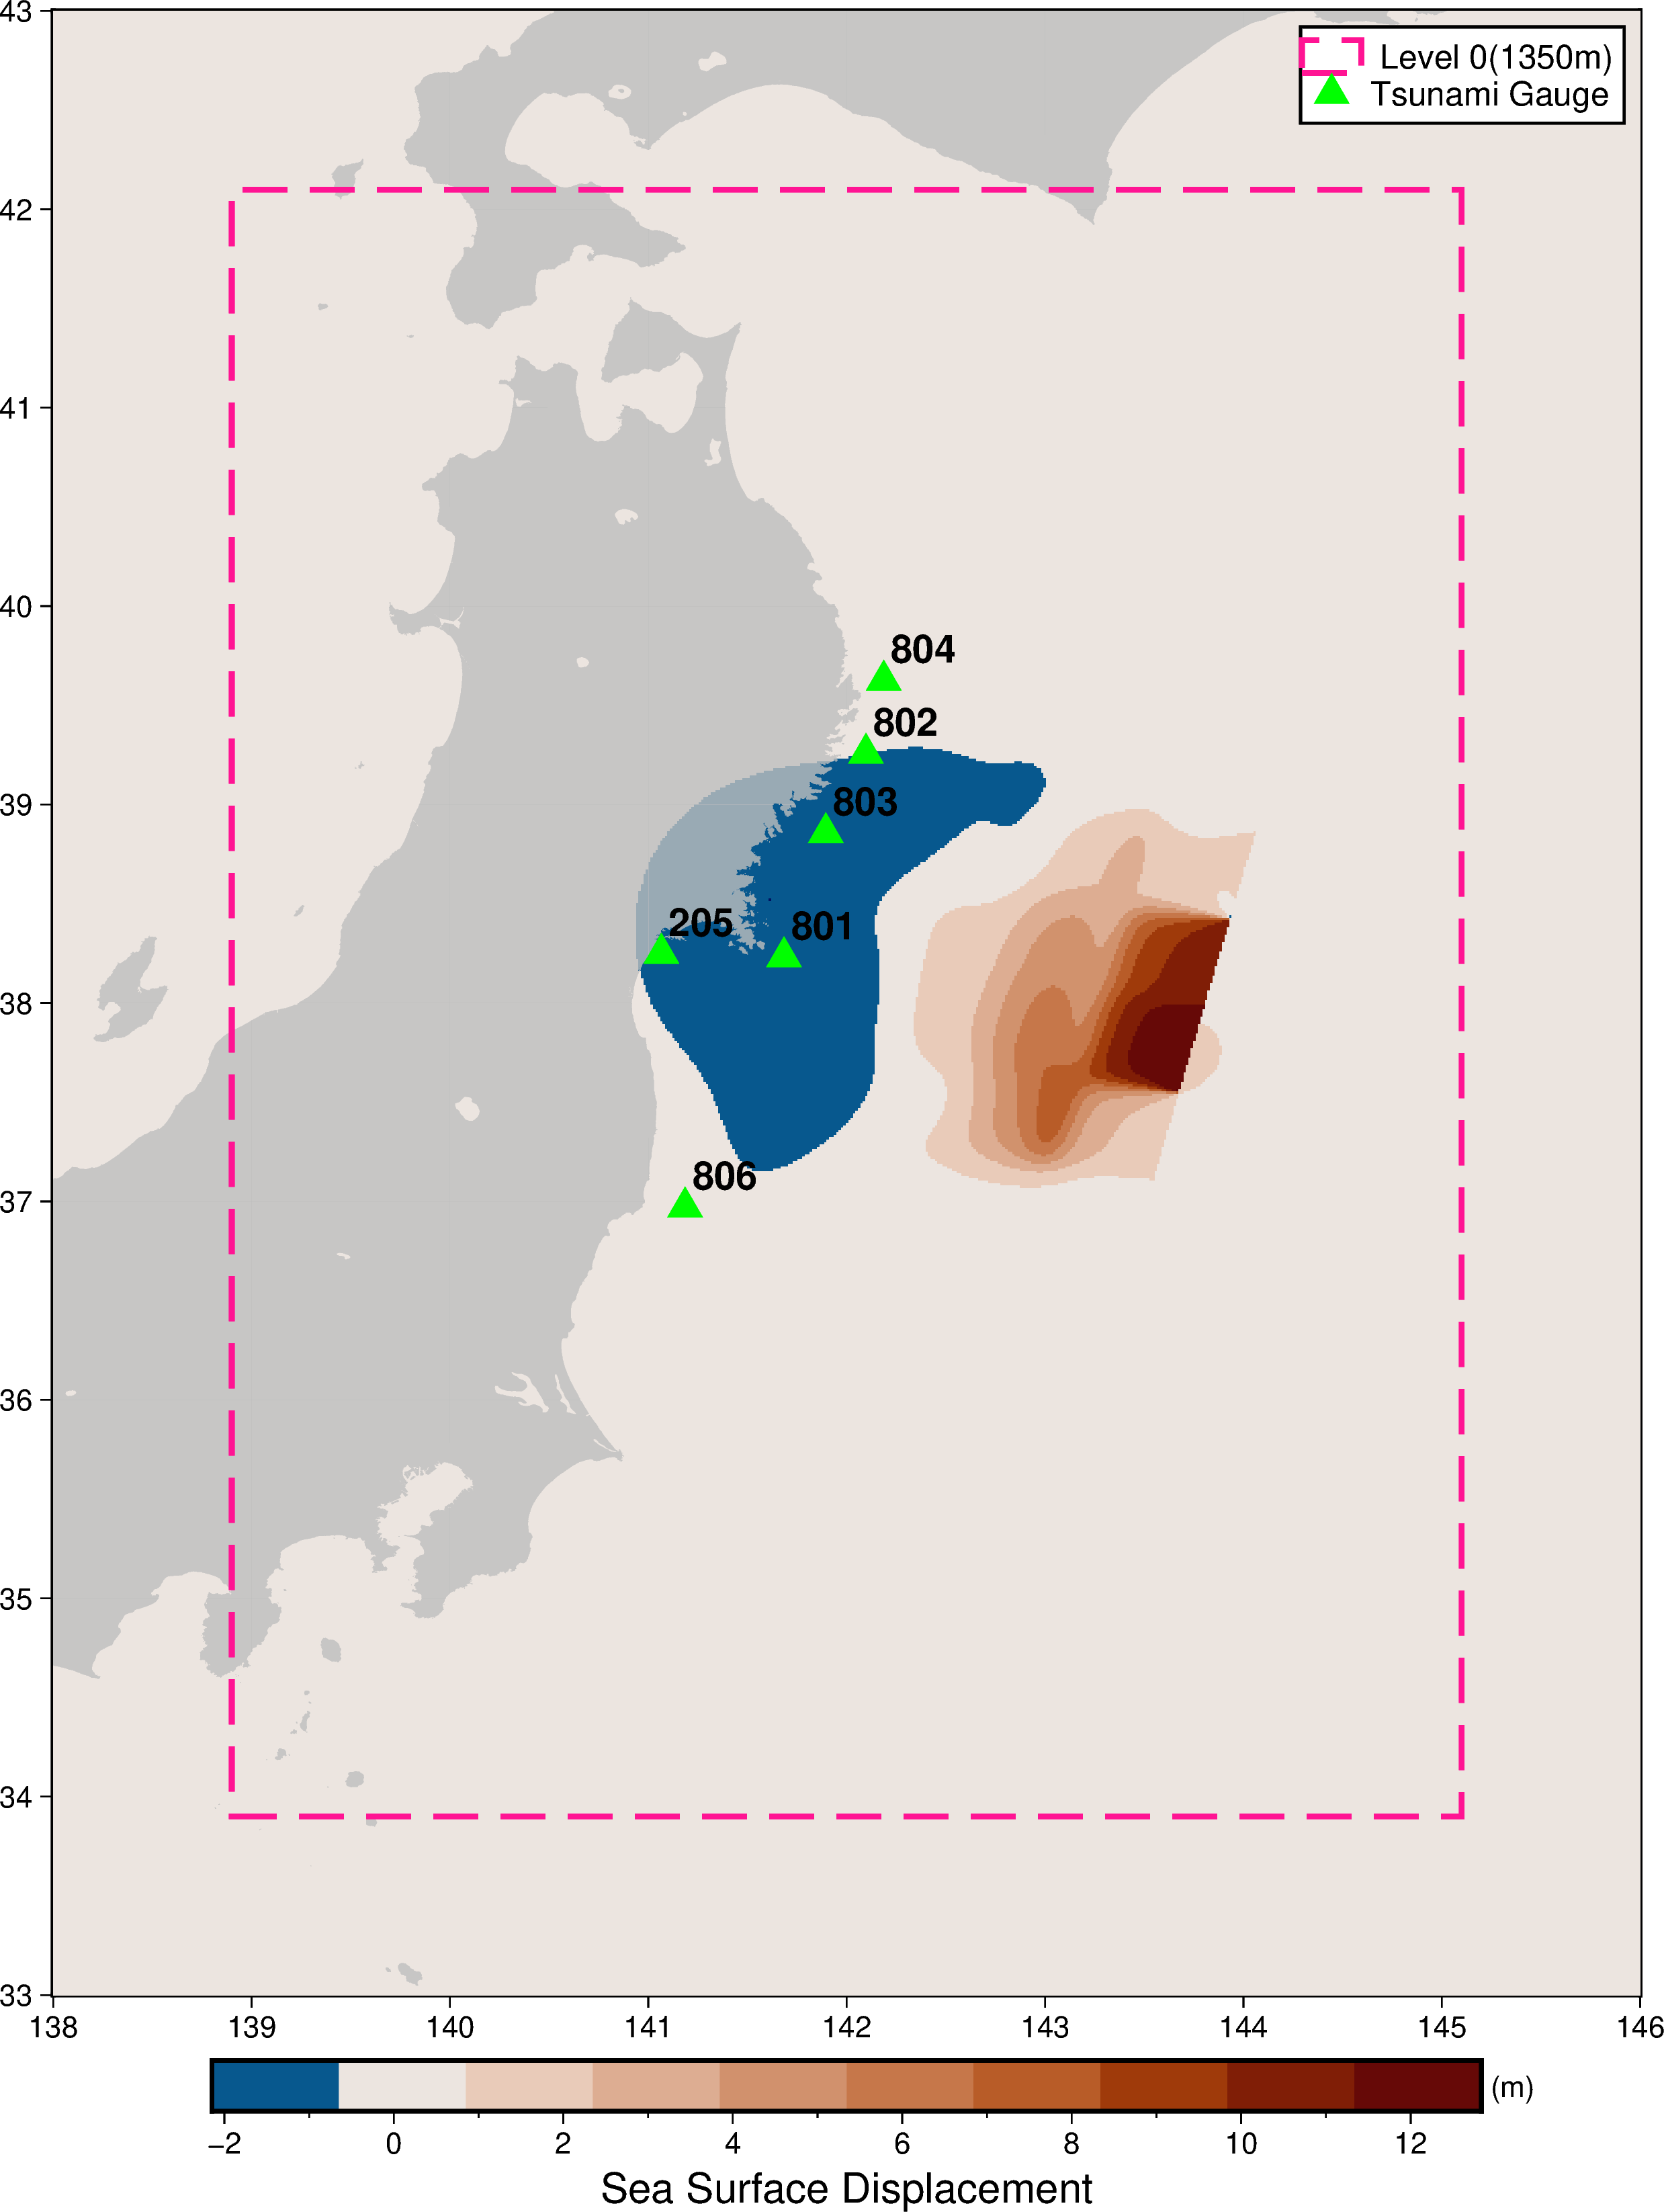

In [2]:
import geopandas as gpd
import numpy as np
import pygmt
import pandas as pd
import os
import rasterio
import xarray as xr

#historic tsunami events
path = '/mnt/data/nragu/Tsunami/Tohoku/gis/dtopo_his/dtopoasc/'
gauges =pd.read_csv("/mnt/data/nragu/Tsunami/Tohoku/gis/2011/Formatted/ObservationLocationInfo.csv")
codelist = [205,801,802,803,804,806]
sel_gauges = gauges[gauges.Code.isin(codelist)]

#find files ending with *_2.asc
filelist = [f for f in os.listdir(path) if f.endswith('_2.asc')]

#filter file name to remove path and _2.asc
filename = [f.replace('_2.asc','') for f in filelist]
filename = [f.replace(path,'') for f in filename]

#raster processing
grid = rasterio.open(path + filelist[0]) #open ascii file
data = grid.read(1) #read 
xlimits = 135,150
ylimits = 45,30
cellsize = 0.01215

# Create coordinates for longitude and latitude
lon = np.linspace(xlimits[0], xlimits[1], data.shape[1])
lat = np.linspace(ylimits[0], ylimits[1], data.shape[0])

# Convert to xarray DataArray
xgrid = xr.DataArray(data, coords=[lat, lon], dims=['lat', 'lon'])
maxval = xgrid.max().values 
minval = xgrid.min().values

#geoclaw model domain extent
domain = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/geoclaw/domain.gpkg")
Level0 = domain[domain.Name == '1350']

fig = pygmt.Figure()
pygmt.makecpt(cmap="vik+h0", series=[minval,maxval,(maxval-minval)/10])
fig.basemap(region=[138,146,33,43],projection="x2.5c/2.5c",frame="a") 
fig.grdimage(grid=xgrid,cmap = True)
fig.coast(land= "gray",transparency=20)
fig.plot(data=Level0, pen="2p,deeppink1,-", close=True,label=" Level 0(1350m)")
#add point and annotations for gauges
fig.plot(
    x=sel_gauges.Longitude,
    y=sel_gauges.Latitude,
    style="t0.5c",
    color="Green",
    pen="Green",
    label="Tsunami Gauge",
)

for i in range(len(sel_gauges)):
    fig.text(
        x=sel_gauges['Longitude'].iloc[i],
        y=sel_gauges['Latitude'].iloc[i],
        text=sel_gauges['Code'].iloc[i],
        font="14p,Helvetica-Bold,black",
        justify="CM",
        offset="0.5c/0.4c",
    )


fig.colorbar(frame=["x+lSea Surface Displacement", "y+l(m)"]) #,position="JMR+o0.5c/0c+w10c/0.5c")
pygmt.config(FONT_ANNOT_PRIMARY="12p")
fig.legend()
fig.savefig("_plot/displacement_fault_fuji.png")
fig.show()


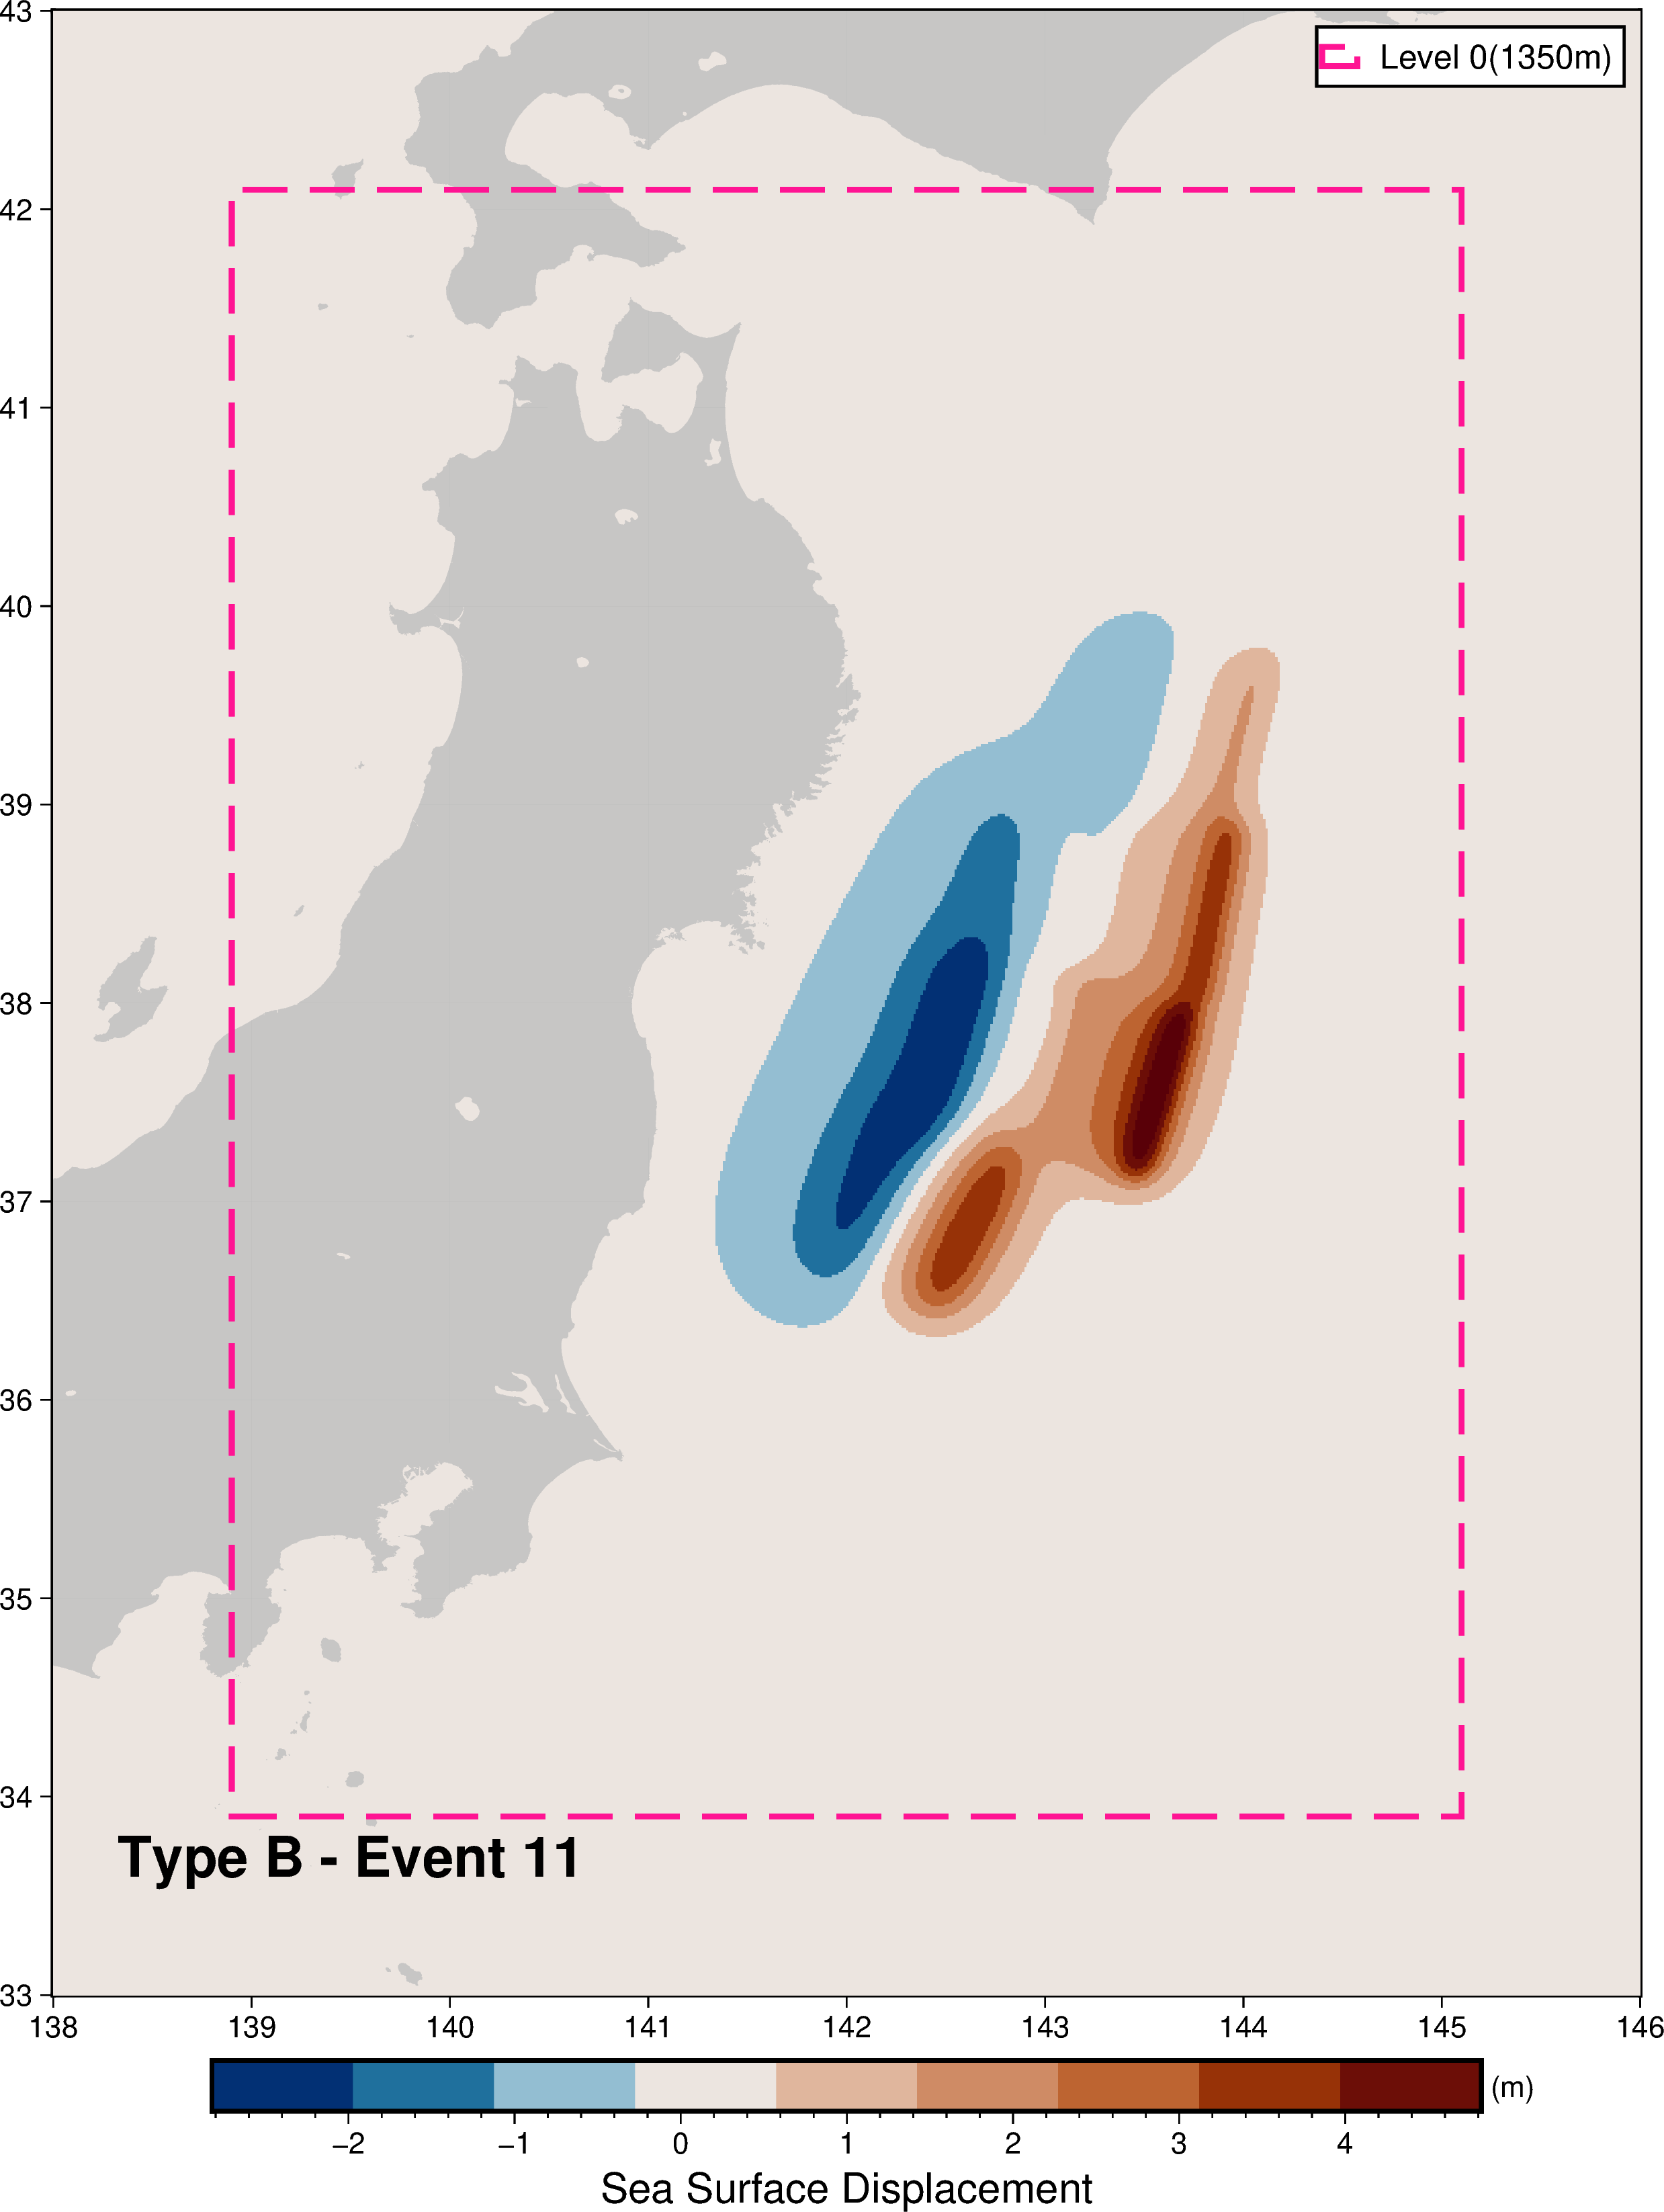

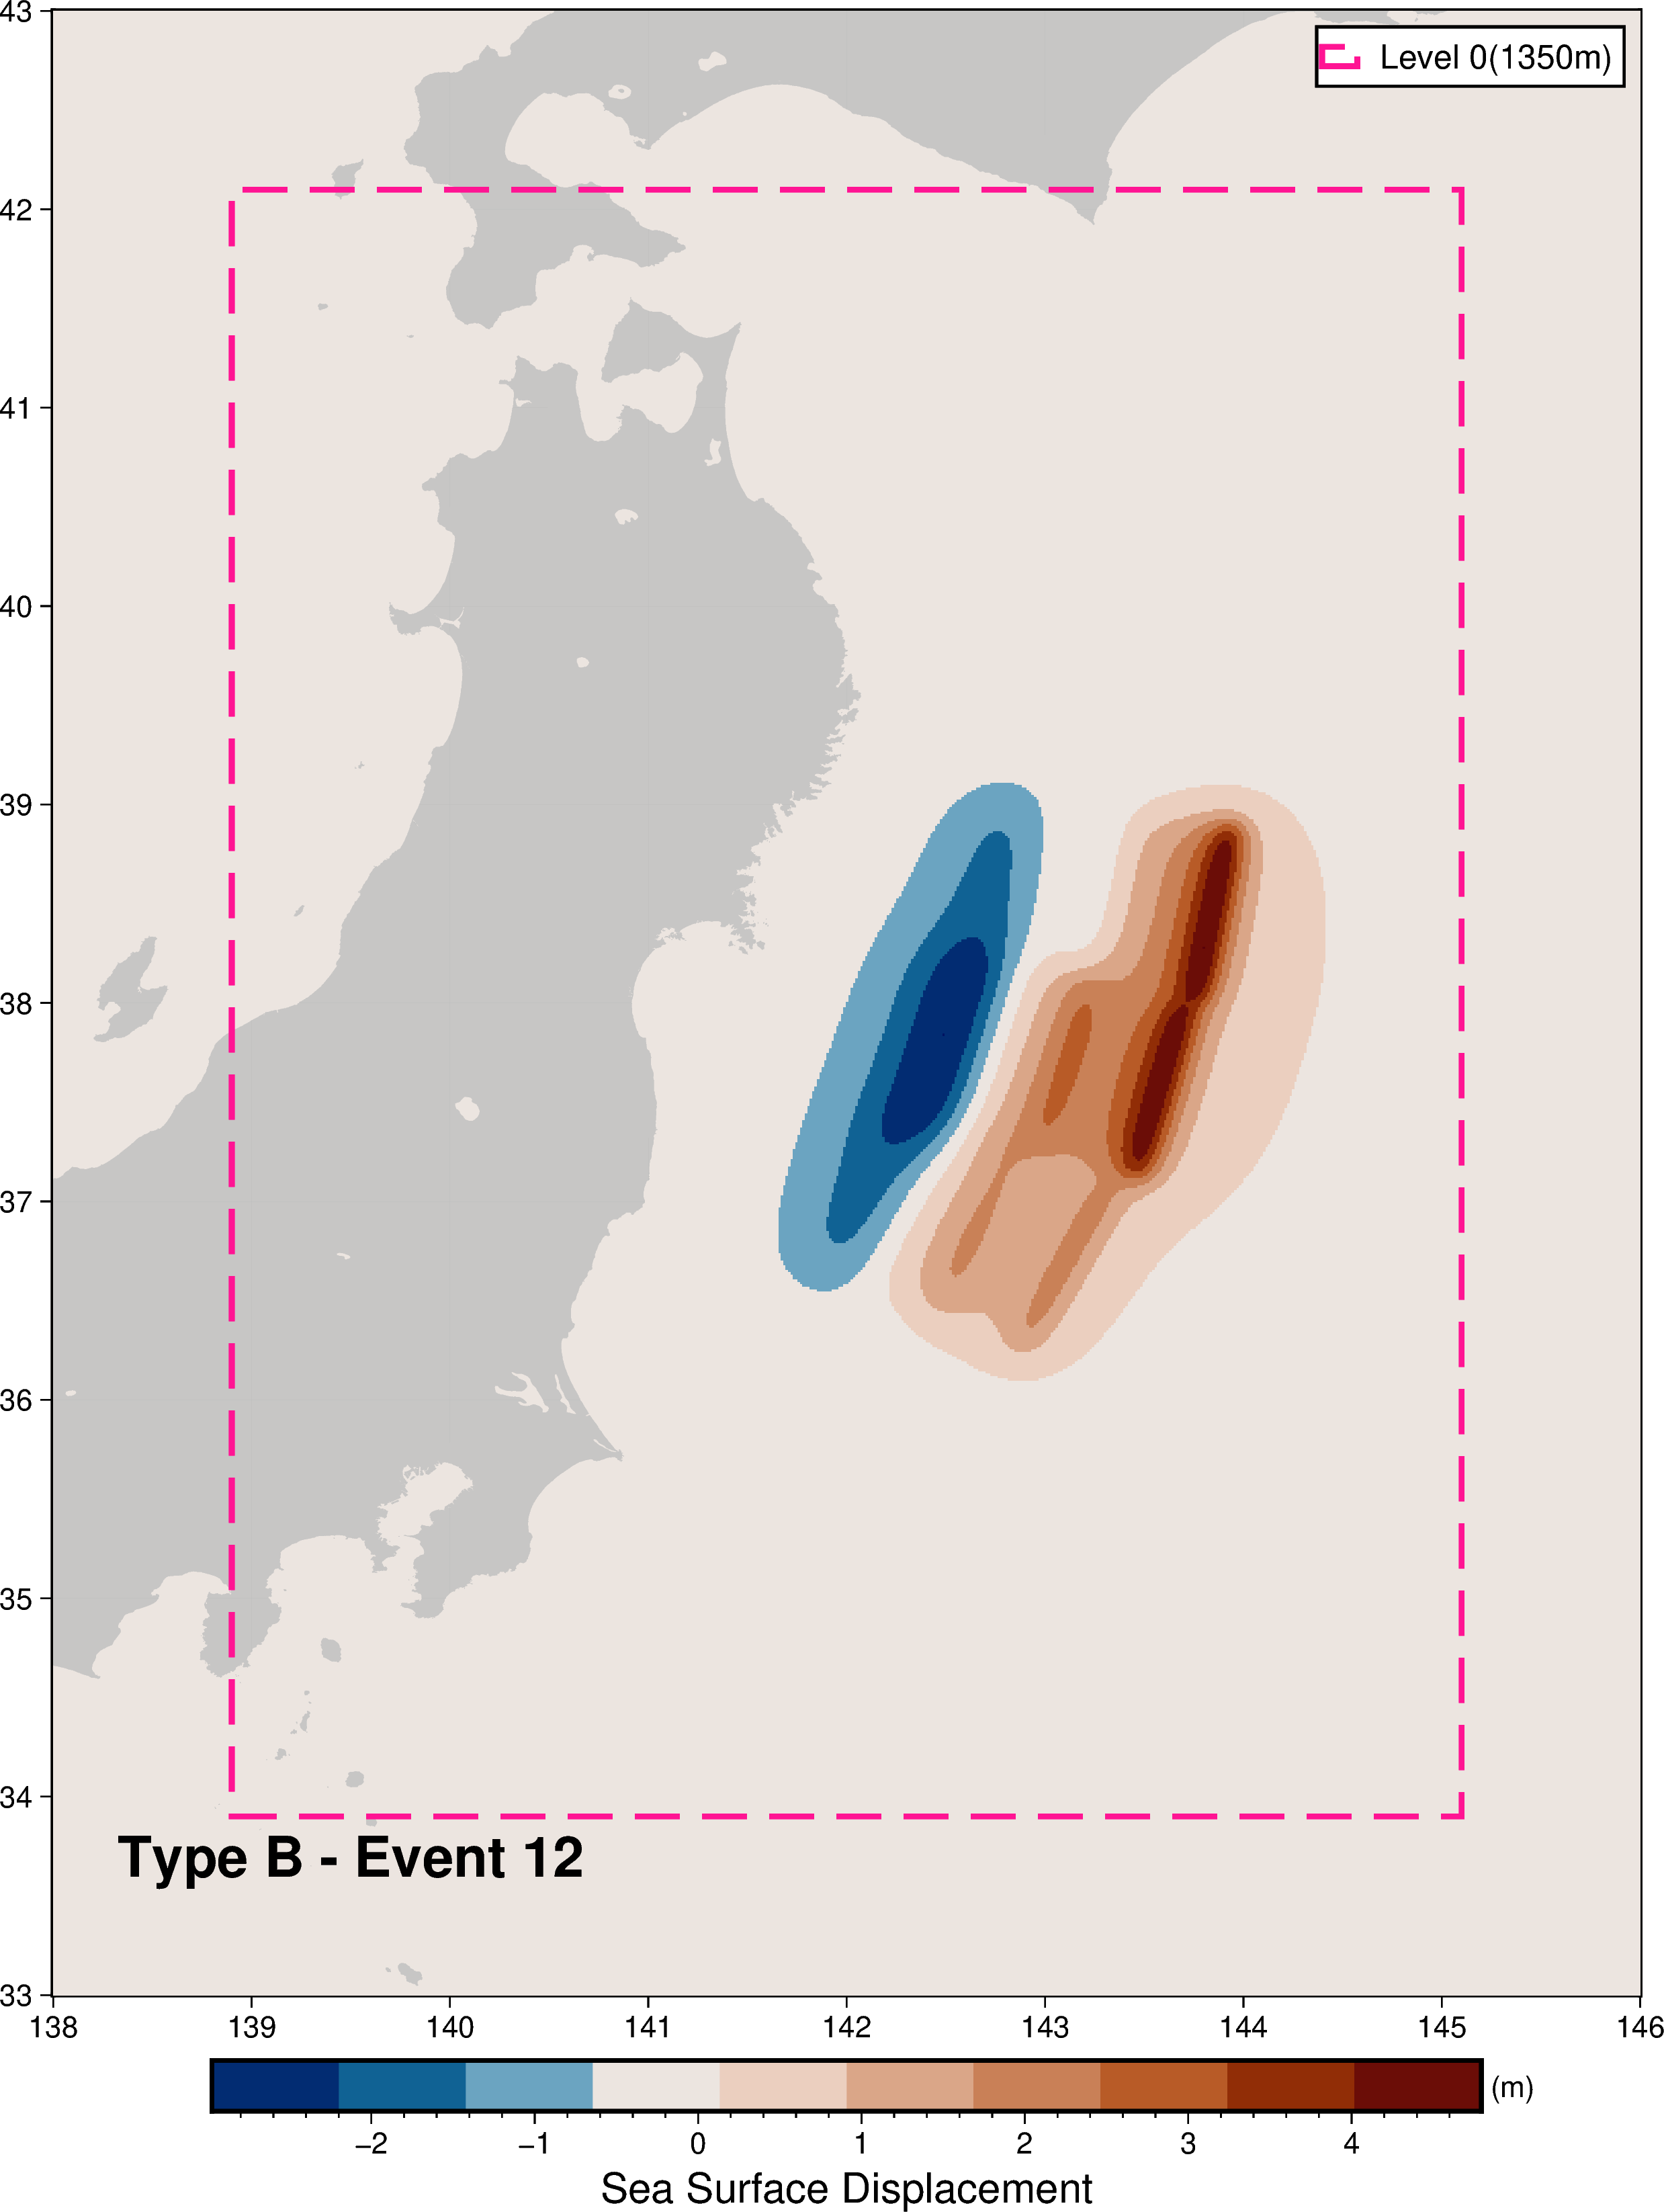

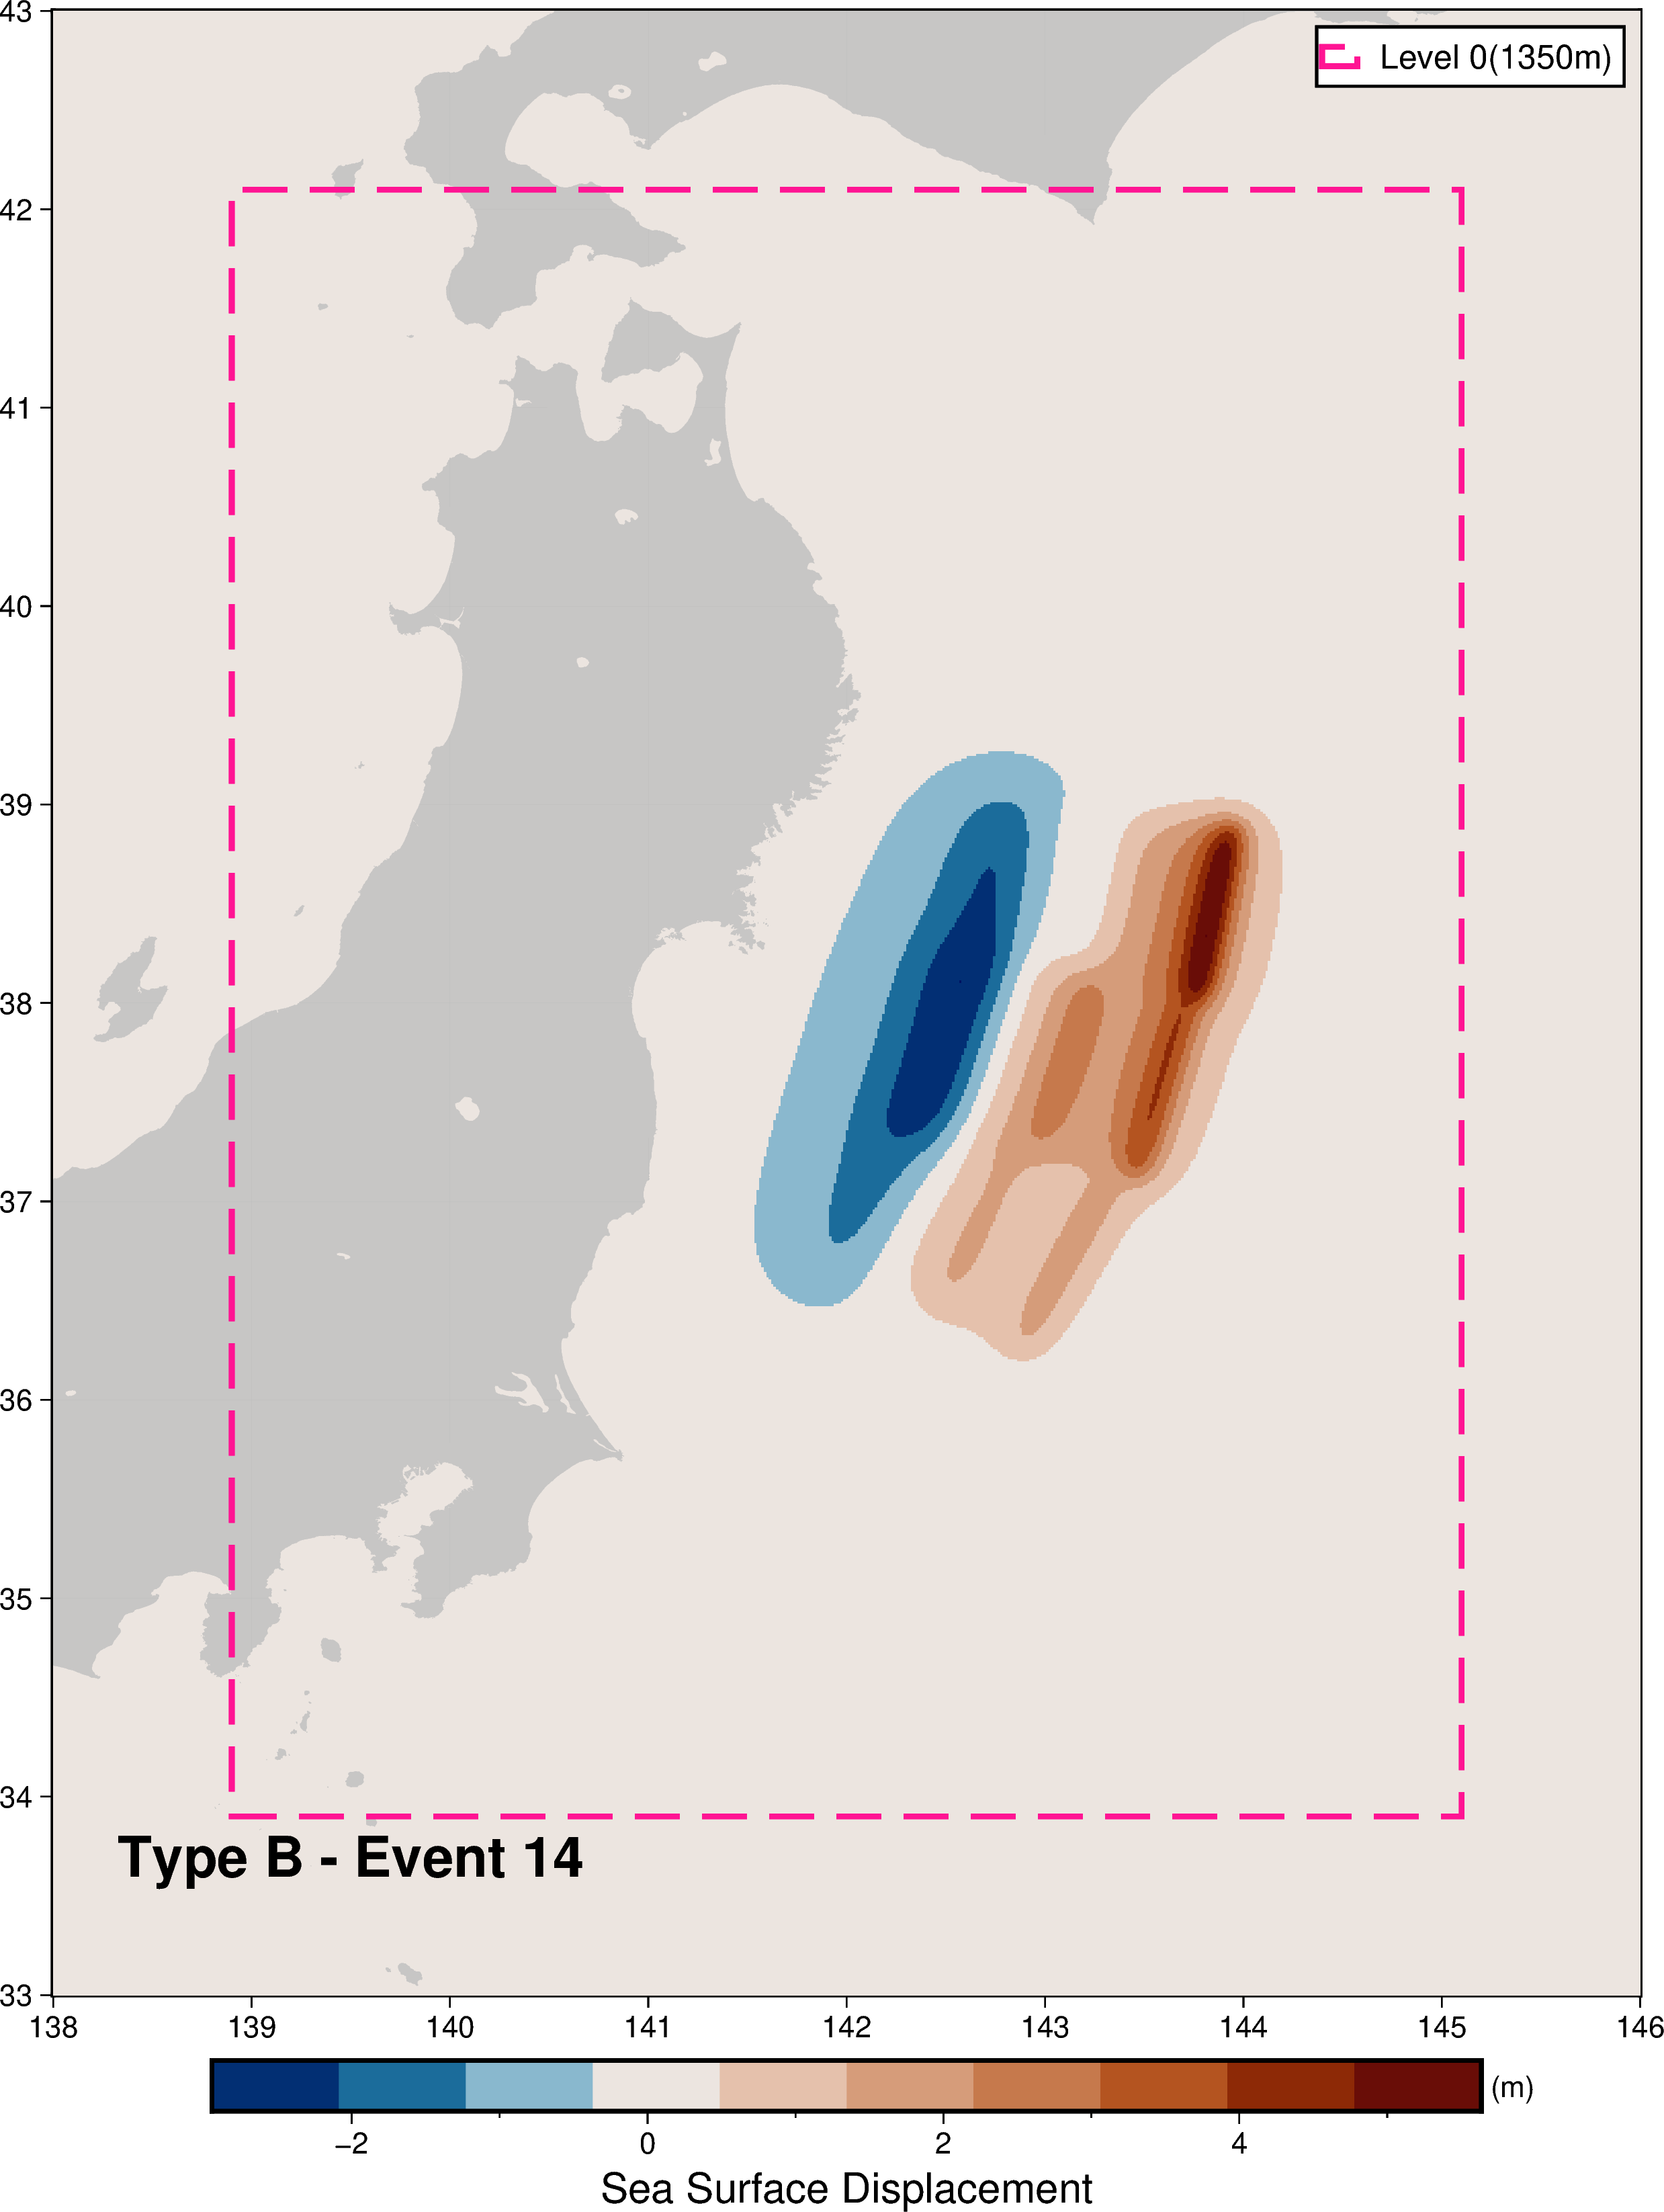

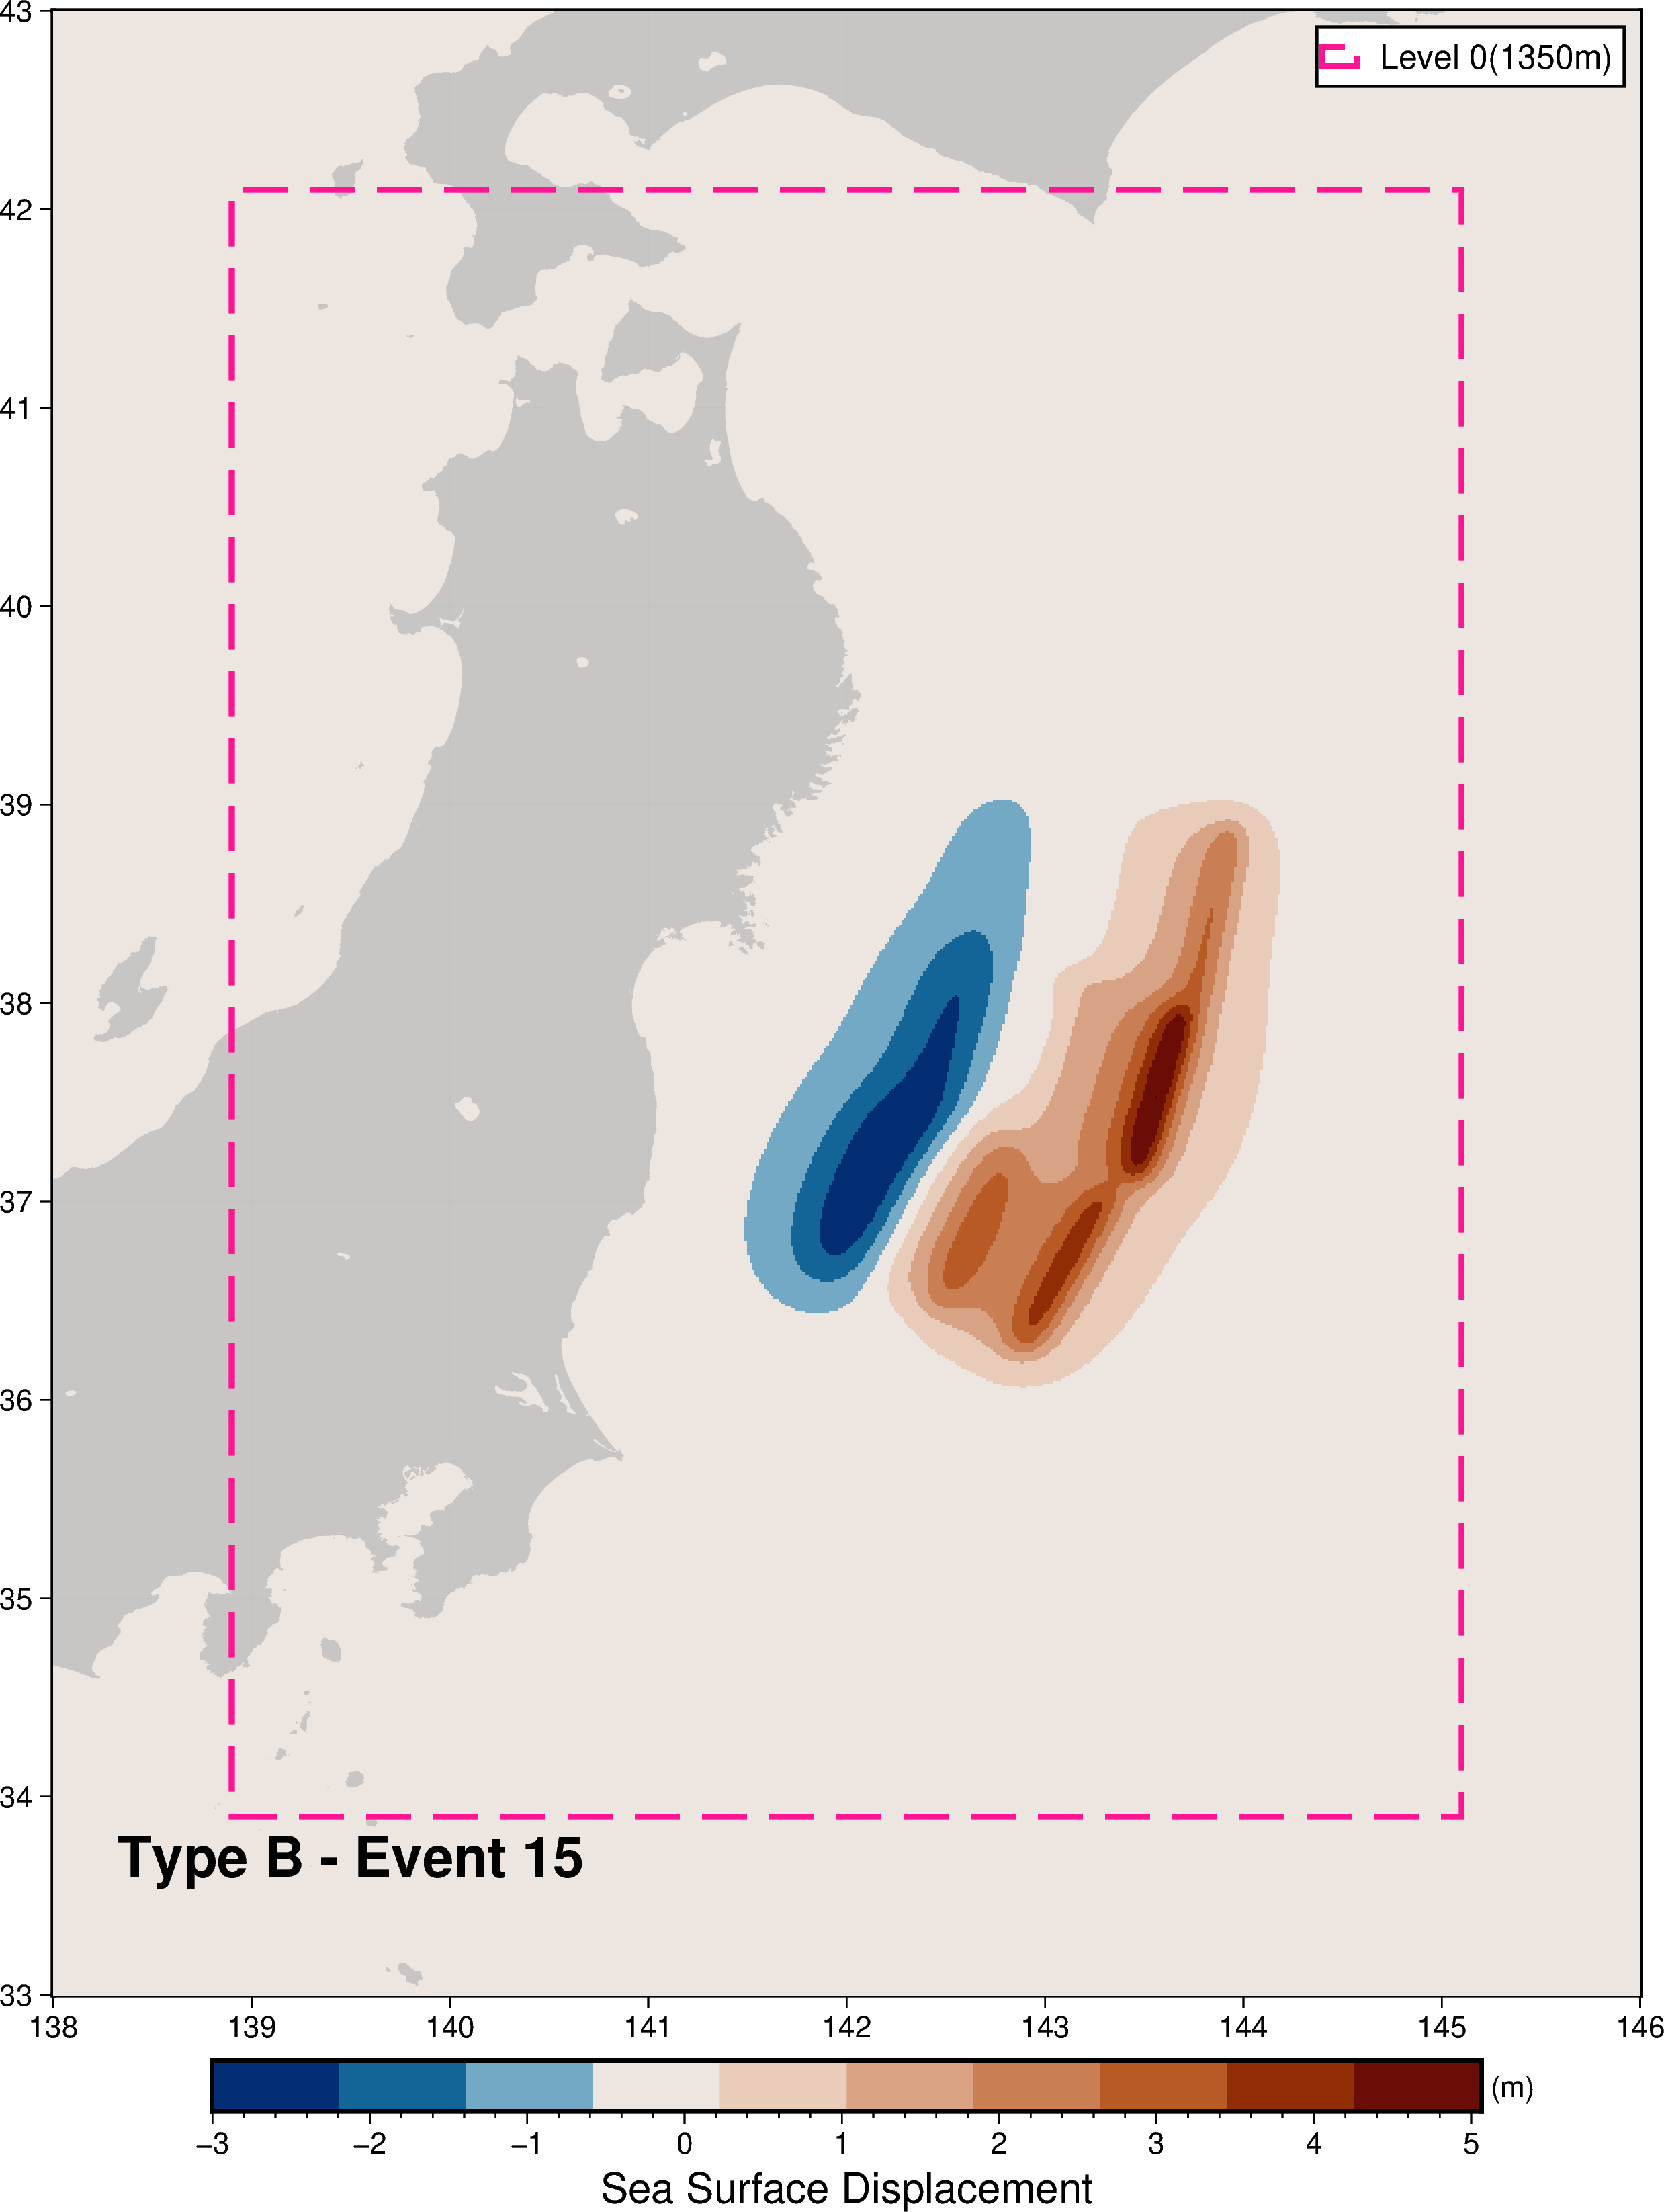

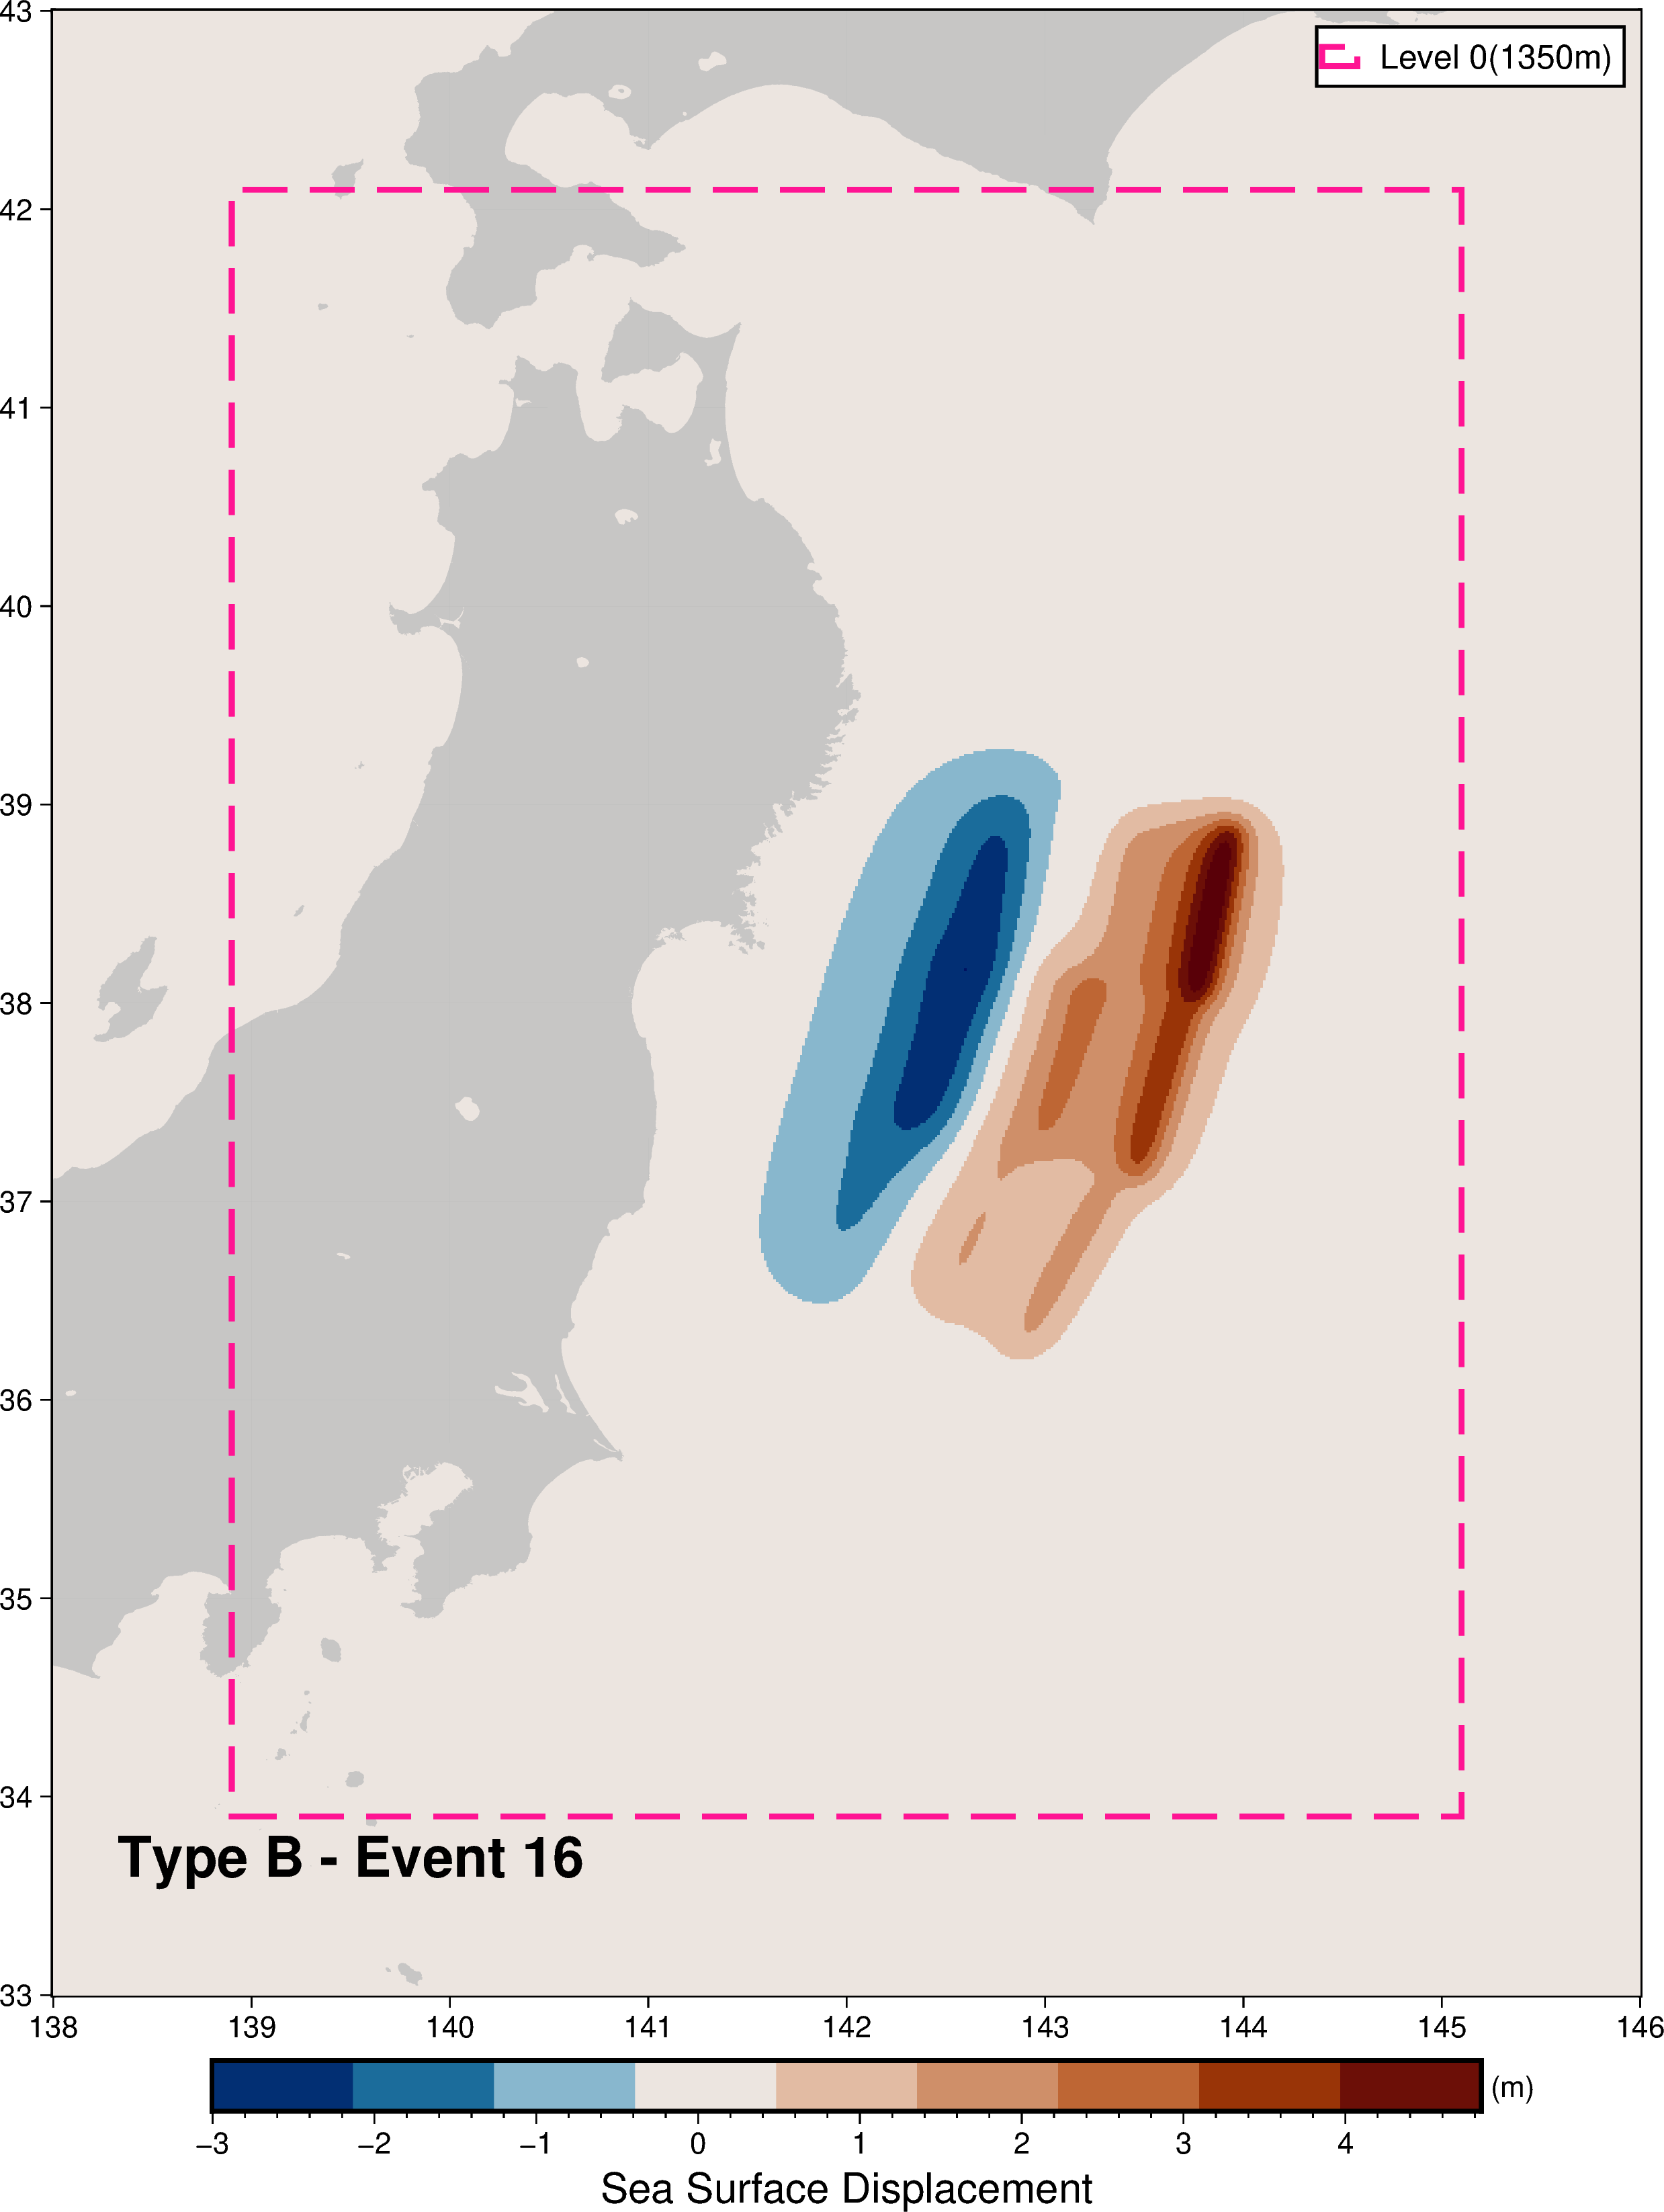

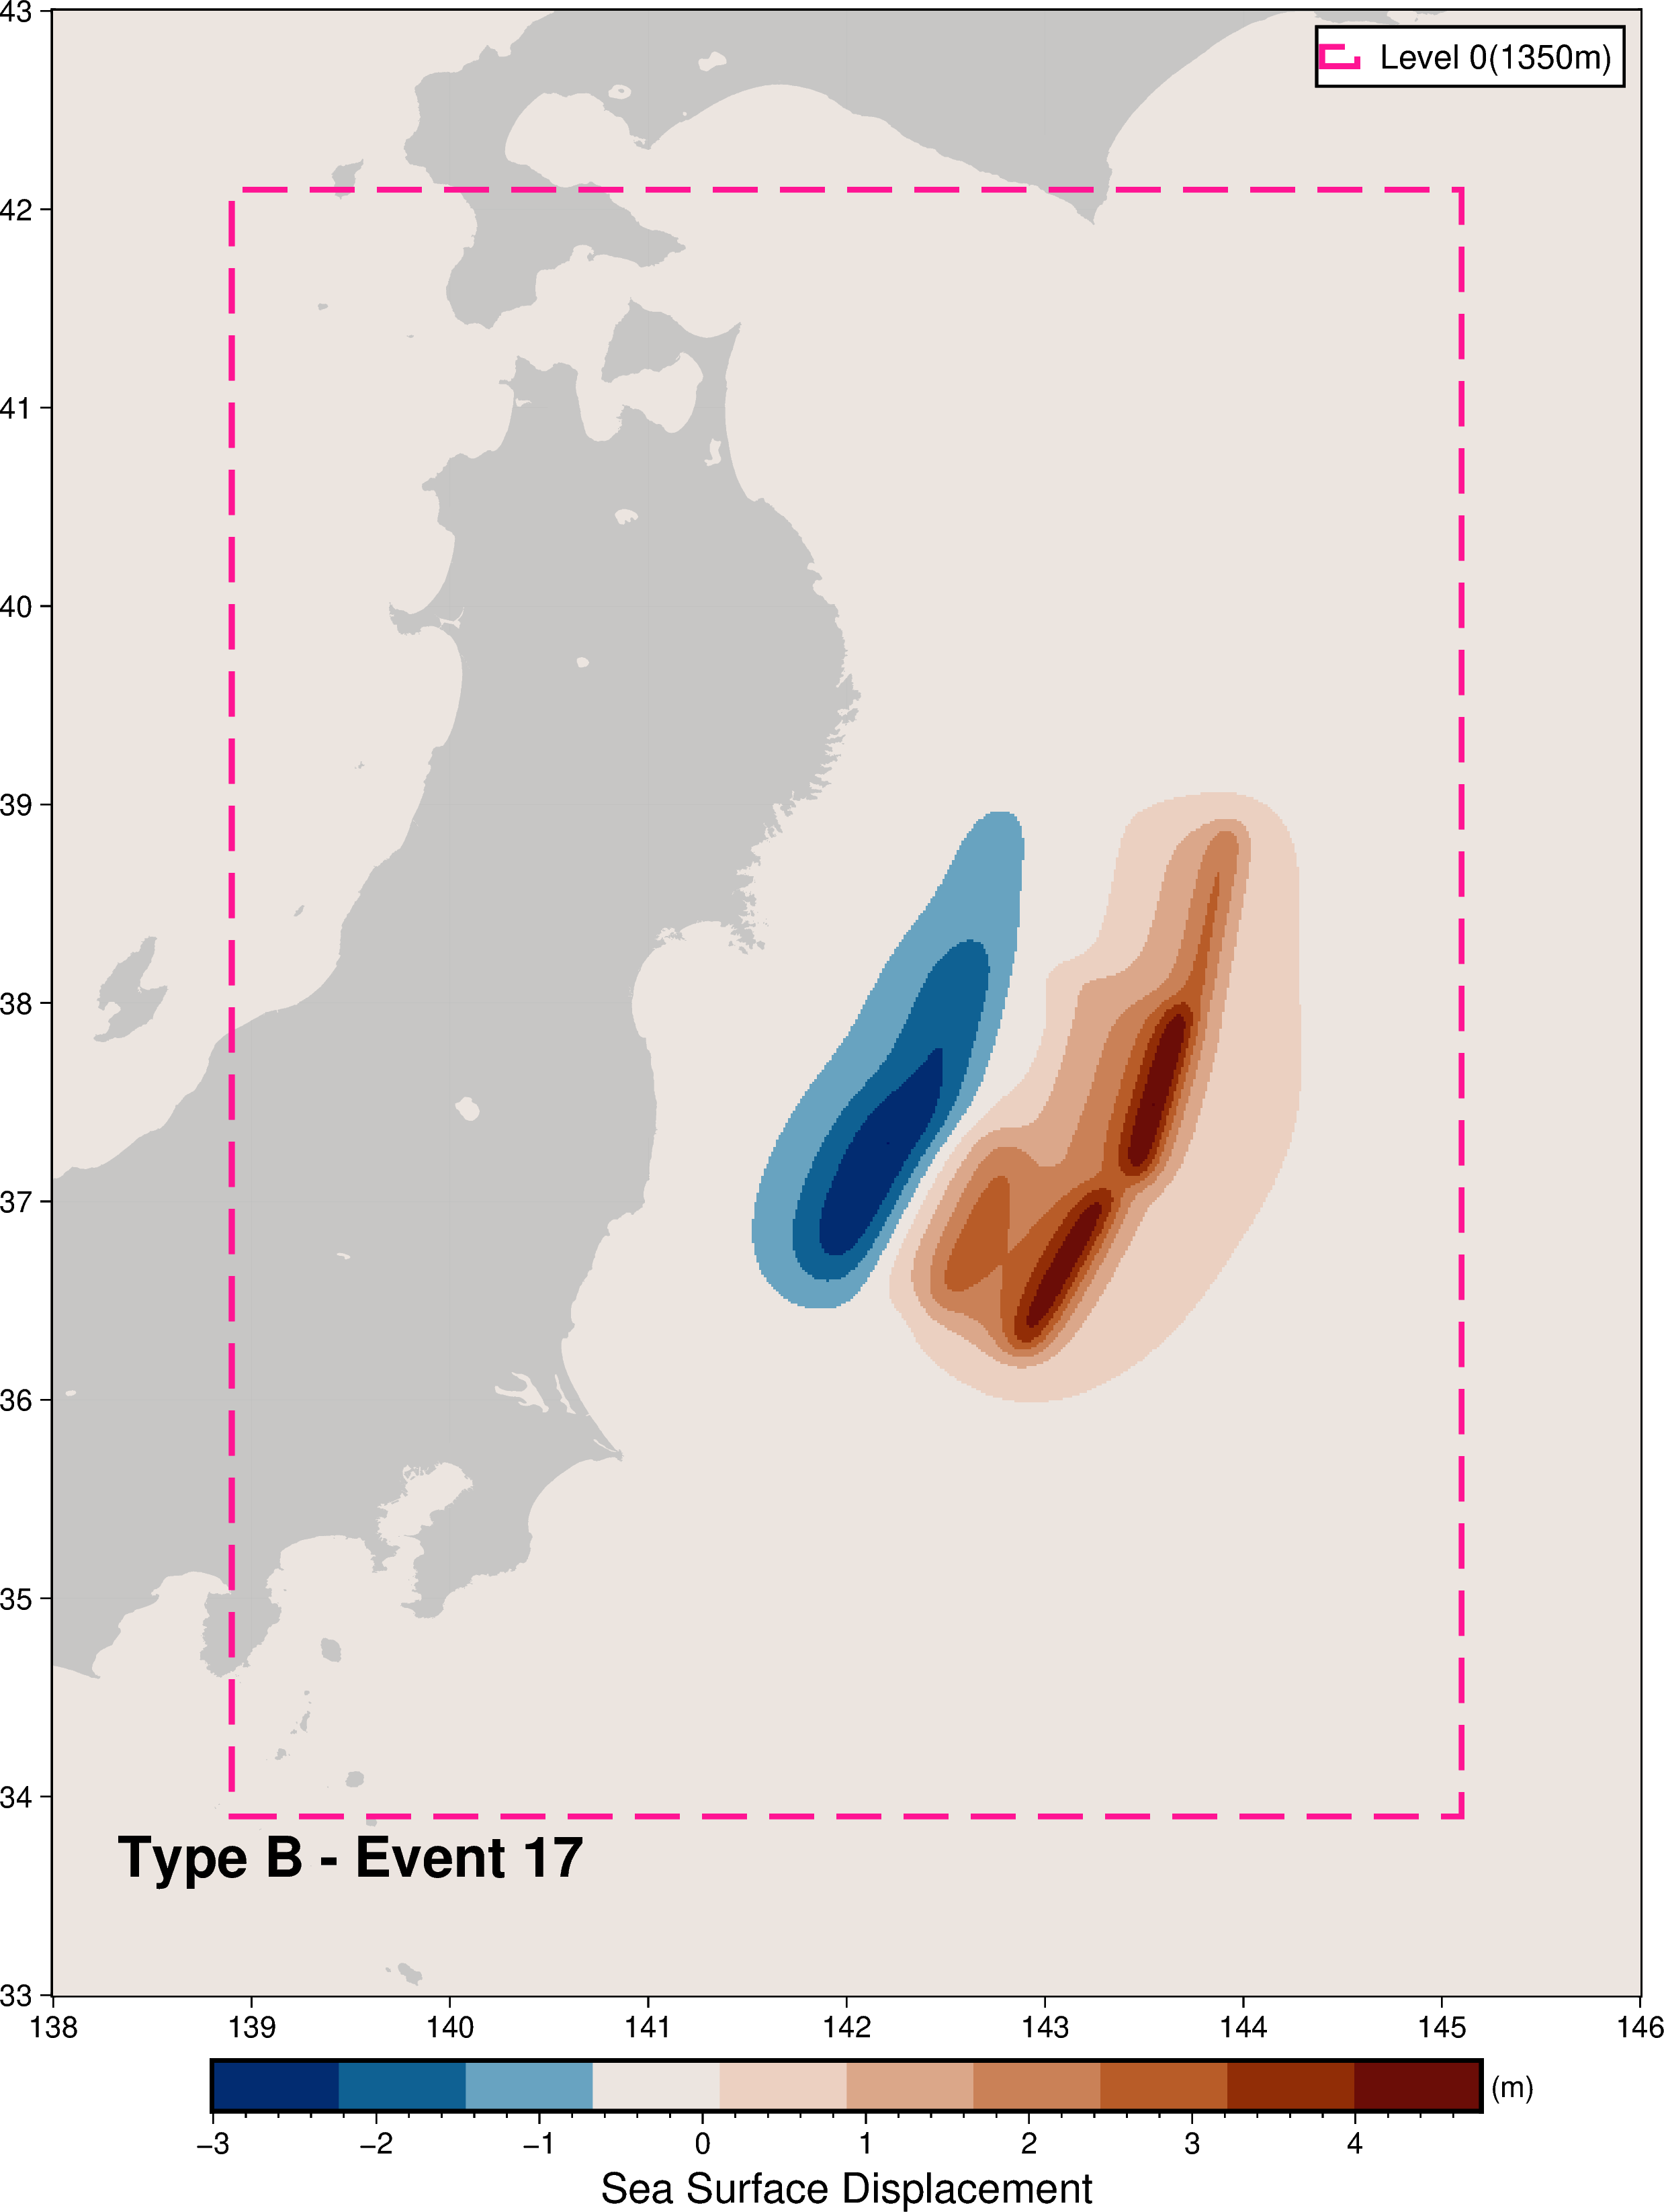

In [9]:
import geopandas as gpd
import numpy as np
import pygmt
import pandas as pd
import os
import rasterio
import xarray as xr

#source
siftpoints = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/GEM/siftpoints.shp")
slabpoints = pd.read_csv("/mnt/data/nragu/Tsunami/Tohoku/gis/GEM/sourceparameters.csv")
events = ['SL_0606','SL_0607','SL_0609','SL_0610','SL_0611','SL_0612']
for event in events:   
    path = '/mnt/data/nragu/Tsunami/Tohoku/gis/dtopo_sift/dtopoasc/'+ event +'.asc'
    if event == 'SL_0606':
        label = 'Type B - Event 11'
    elif event == 'SL_0607':
        label = 'Type B - Event 12'
    elif event == 'SL_0608':
        label = 'Type B - Event 13'
    elif event == 'SL_0609':
        label = 'Type B - Event 14'
    elif event == 'SL_0610':
        label = 'Type B - Event 15'
    elif event == 'SL_0611':
        label = 'Type B - Event 16'
    elif event == 'SL_0612':
        label = 'Type B - Event 17'

    #raster processing
    grid = rasterio.open(path) #open ascii file
    data = grid.read(1) #read 
    xlimits = 135,150
    ylimits = 45,30
    cellsize = 0.01215

    # Create coordinates for longitude and latitude
    lon = np.linspace(xlimits[0], xlimits[1], data.shape[1])
    lat = np.linspace(ylimits[0], ylimits[1], data.shape[0])

    # Convert to xarray DataArray
    xgrid = xr.DataArray(data, coords=[lat, lon], dims=['lat', 'lon'])
    maxval = xgrid.max().values 
    minval = xgrid.min().values

    #geoclaw model domain extent
    domain = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/geoclaw/domain.gpkg")
    Level0 = domain[domain.Name == '1350']

    fig = pygmt.Figure()
    pygmt.makecpt(cmap="vik+h0", series=[minval,maxval,(maxval-minval)/10])
    fig.basemap(region=[138,146,33,43],projection="x2.5c/2.5c",frame="a") 
    fig.grdimage(grid=xgrid,cmap = True)
    fig.coast(land= "gray",transparency=20)
    fig.plot(data=Level0, pen="2p,deeppink1,-", close=True,label=" Level 0(1350m)")
    fig.colorbar(frame=["x+lSea Surface Displacement", "y+l(m)"])#,position="JMR+o0.5c/0c+w10c/0.5c")
    pygmt.config(FONT_ANNOT_PRIMARY="12p")
    fig.legend()
    fig.savefig('_plots/displacement_t2_'+event+'.png')
    fig.text(x=139.5,y=33.5,text=label,font="20p,Helvetica-Bold,black",justify="CM",offset="0c/0.5c")
    fig.show()

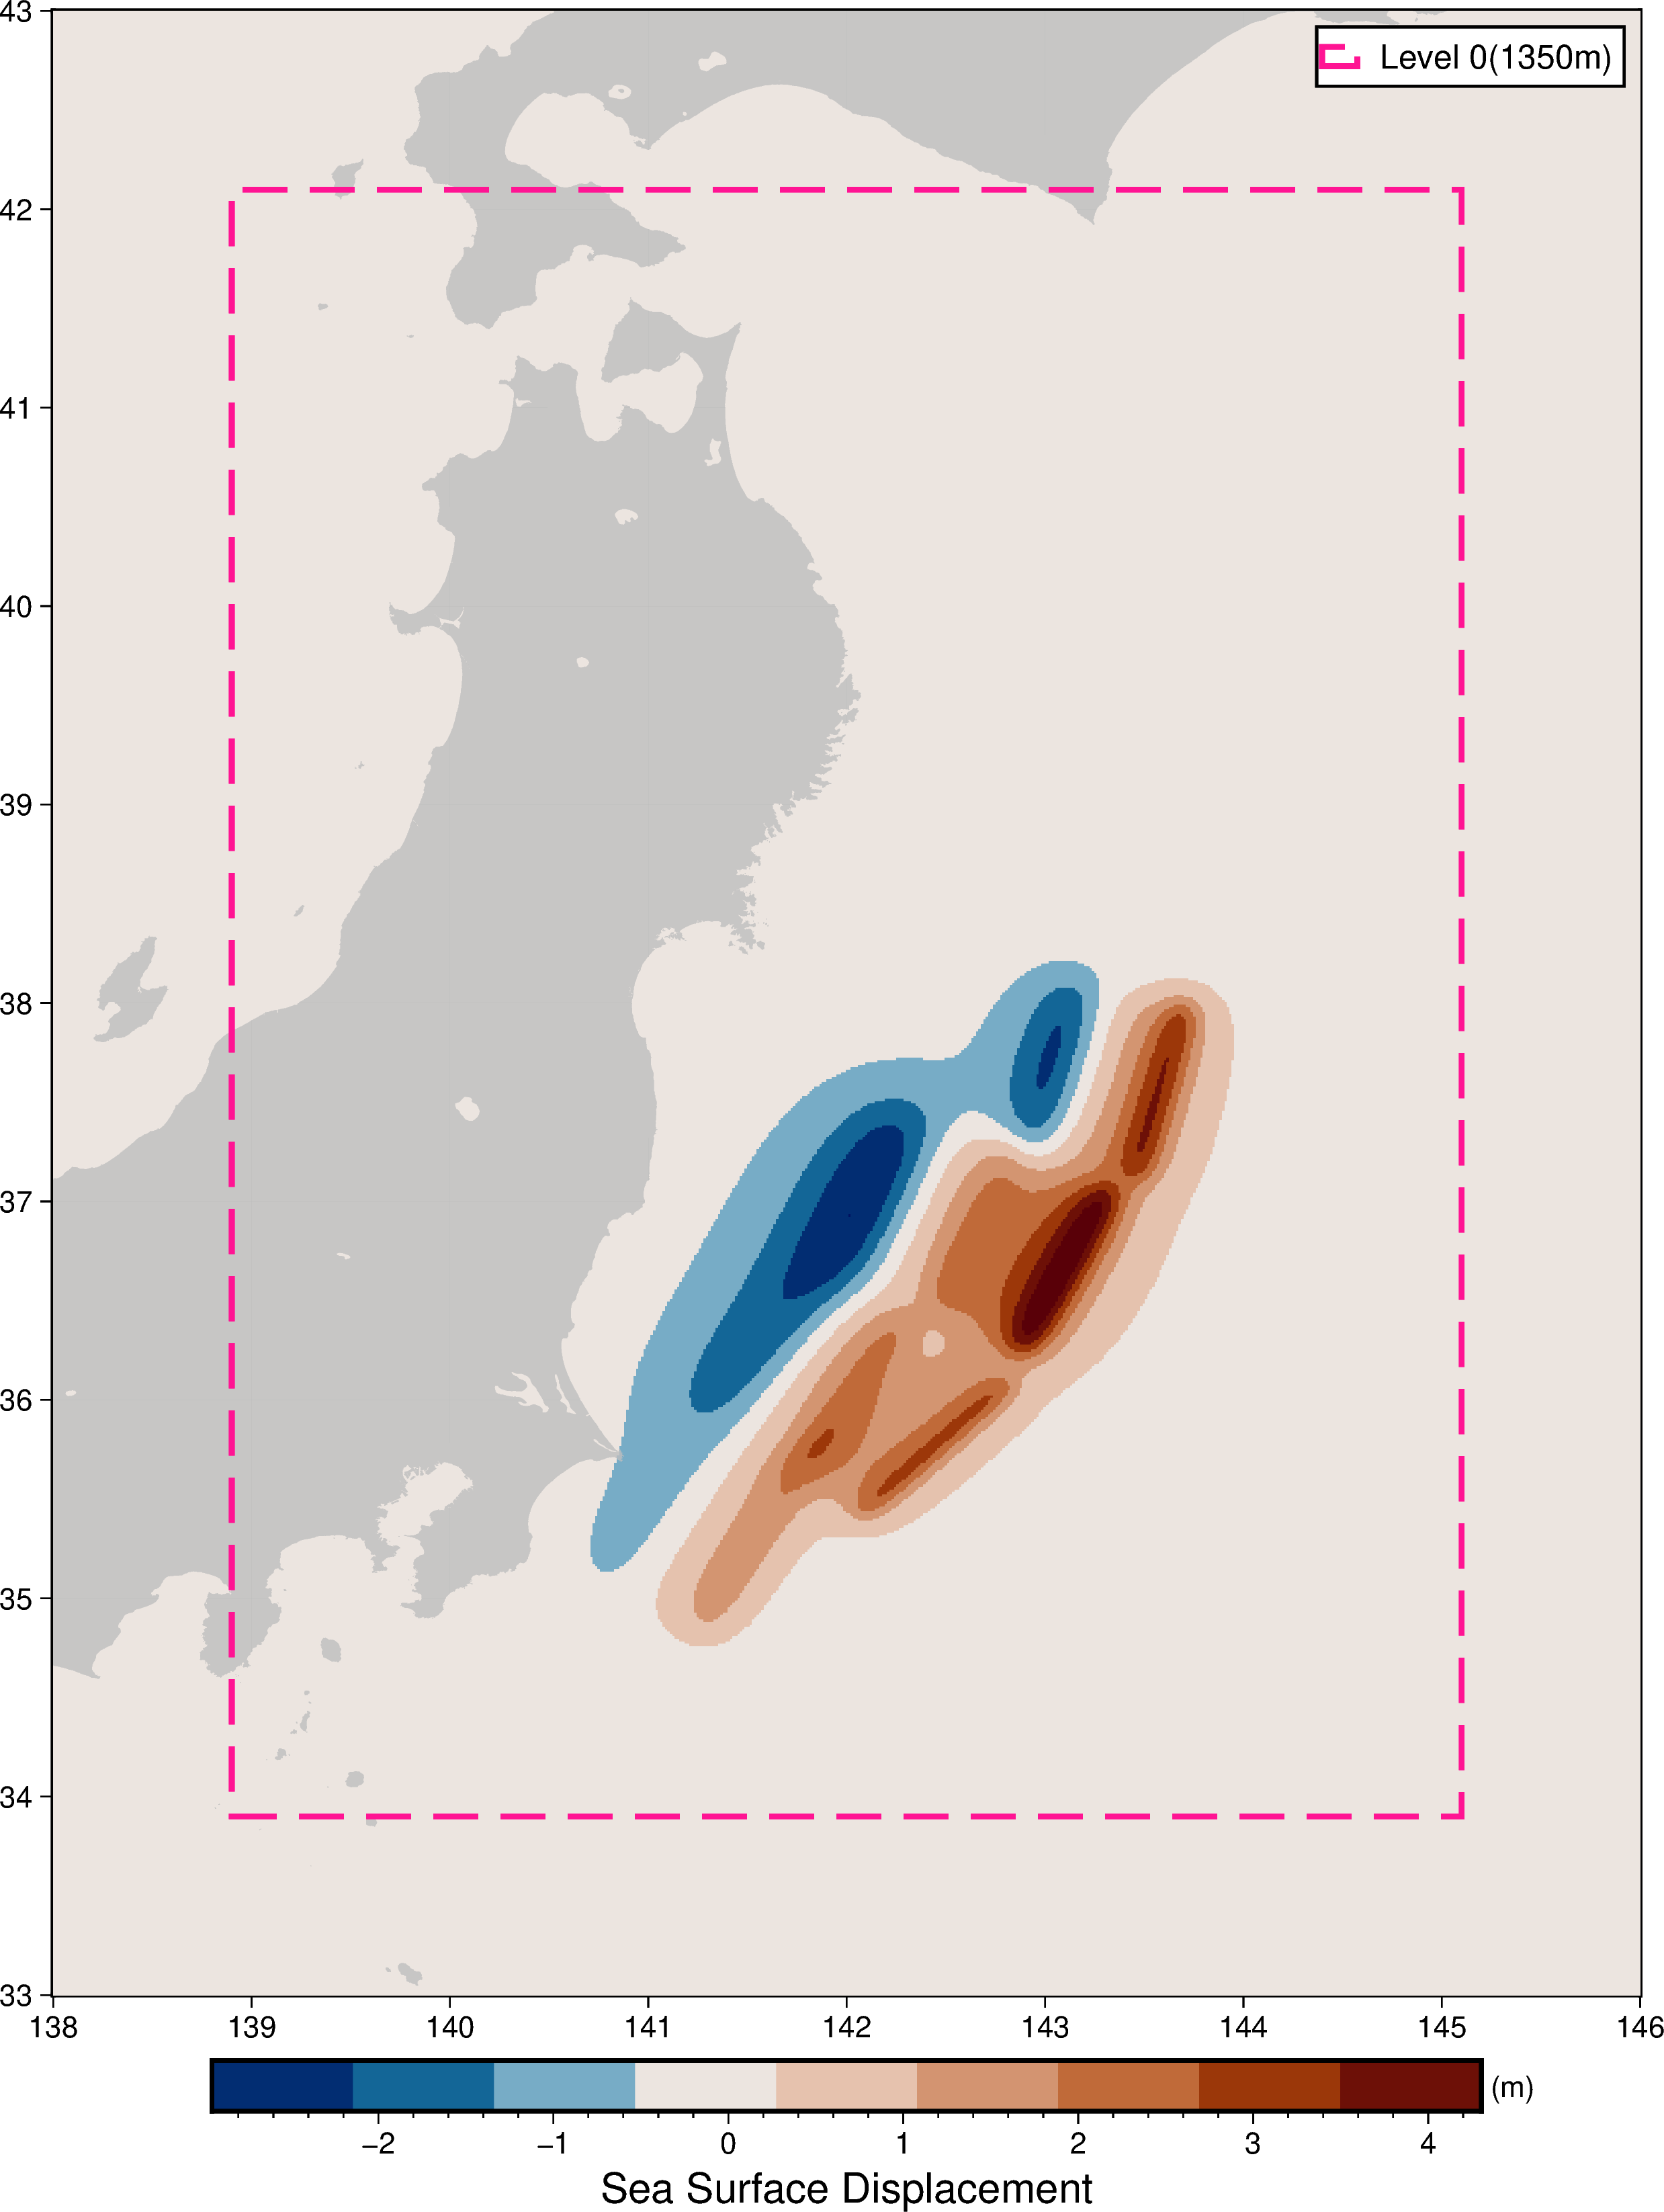

In [13]:
import geopandas as gpd
import numpy as np
import pygmt
import pandas as pd
import os
import rasterio
import xarray as xr

#source
siftpoints = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/GEM/siftpoints.shp")
slabpoints = pd.read_csv("/mnt/data/nragu/Tsunami/Tohoku/gis/GEM/sourceparameters.csv")
path = '/mnt/data/nragu/Tsunami/Tohoku/gis/dtopo_sift/dtopoasc/SL_0627.asc'

#raster processing
grid = rasterio.open(path) #open ascii file
data = grid.read(1) #read 
xlimits = 135,150
ylimits = 45,30
cellsize = 0.01215

# Create coordinates for longitude and latitude
lon = np.linspace(xlimits[0], xlimits[1], data.shape[1])
lat = np.linspace(ylimits[0], ylimits[1], data.shape[0])

# Convert to xarray DataArray
xgrid = xr.DataArray(data, coords=[lat, lon], dims=['lat', 'lon'])
maxval = xgrid.max().values 
minval = xgrid.min().values

#geoclaw model domain extent
domain = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/geoclaw/domain.gpkg")
Level0 = domain[domain.Name == '1350']

fig = pygmt.Figure()
pygmt.makecpt(cmap="vik+h0", series=[minval,maxval,(maxval-minval)/10])
fig.basemap(region=[138,146,33,43],projection="x2.5c/2.5c",frame="a") 
fig.grdimage(grid=xgrid,cmap = True)
fig.coast(land= "gray",transparency=20)
fig.plot(data=Level0, pen="2p,deeppink1,-", close=True,label=" Level 0(1350m)")
fig.colorbar(frame=["x+lSea Surface Displacement", "y+l(m)"])#,position="JMR+o0.5c/0c+w10c/0.5c")
pygmt.config(FONT_ANNOT_PRIMARY="12p")
fig.legend()
fig.savefig("_plot/displacement_t2-627.png")
fig.show()

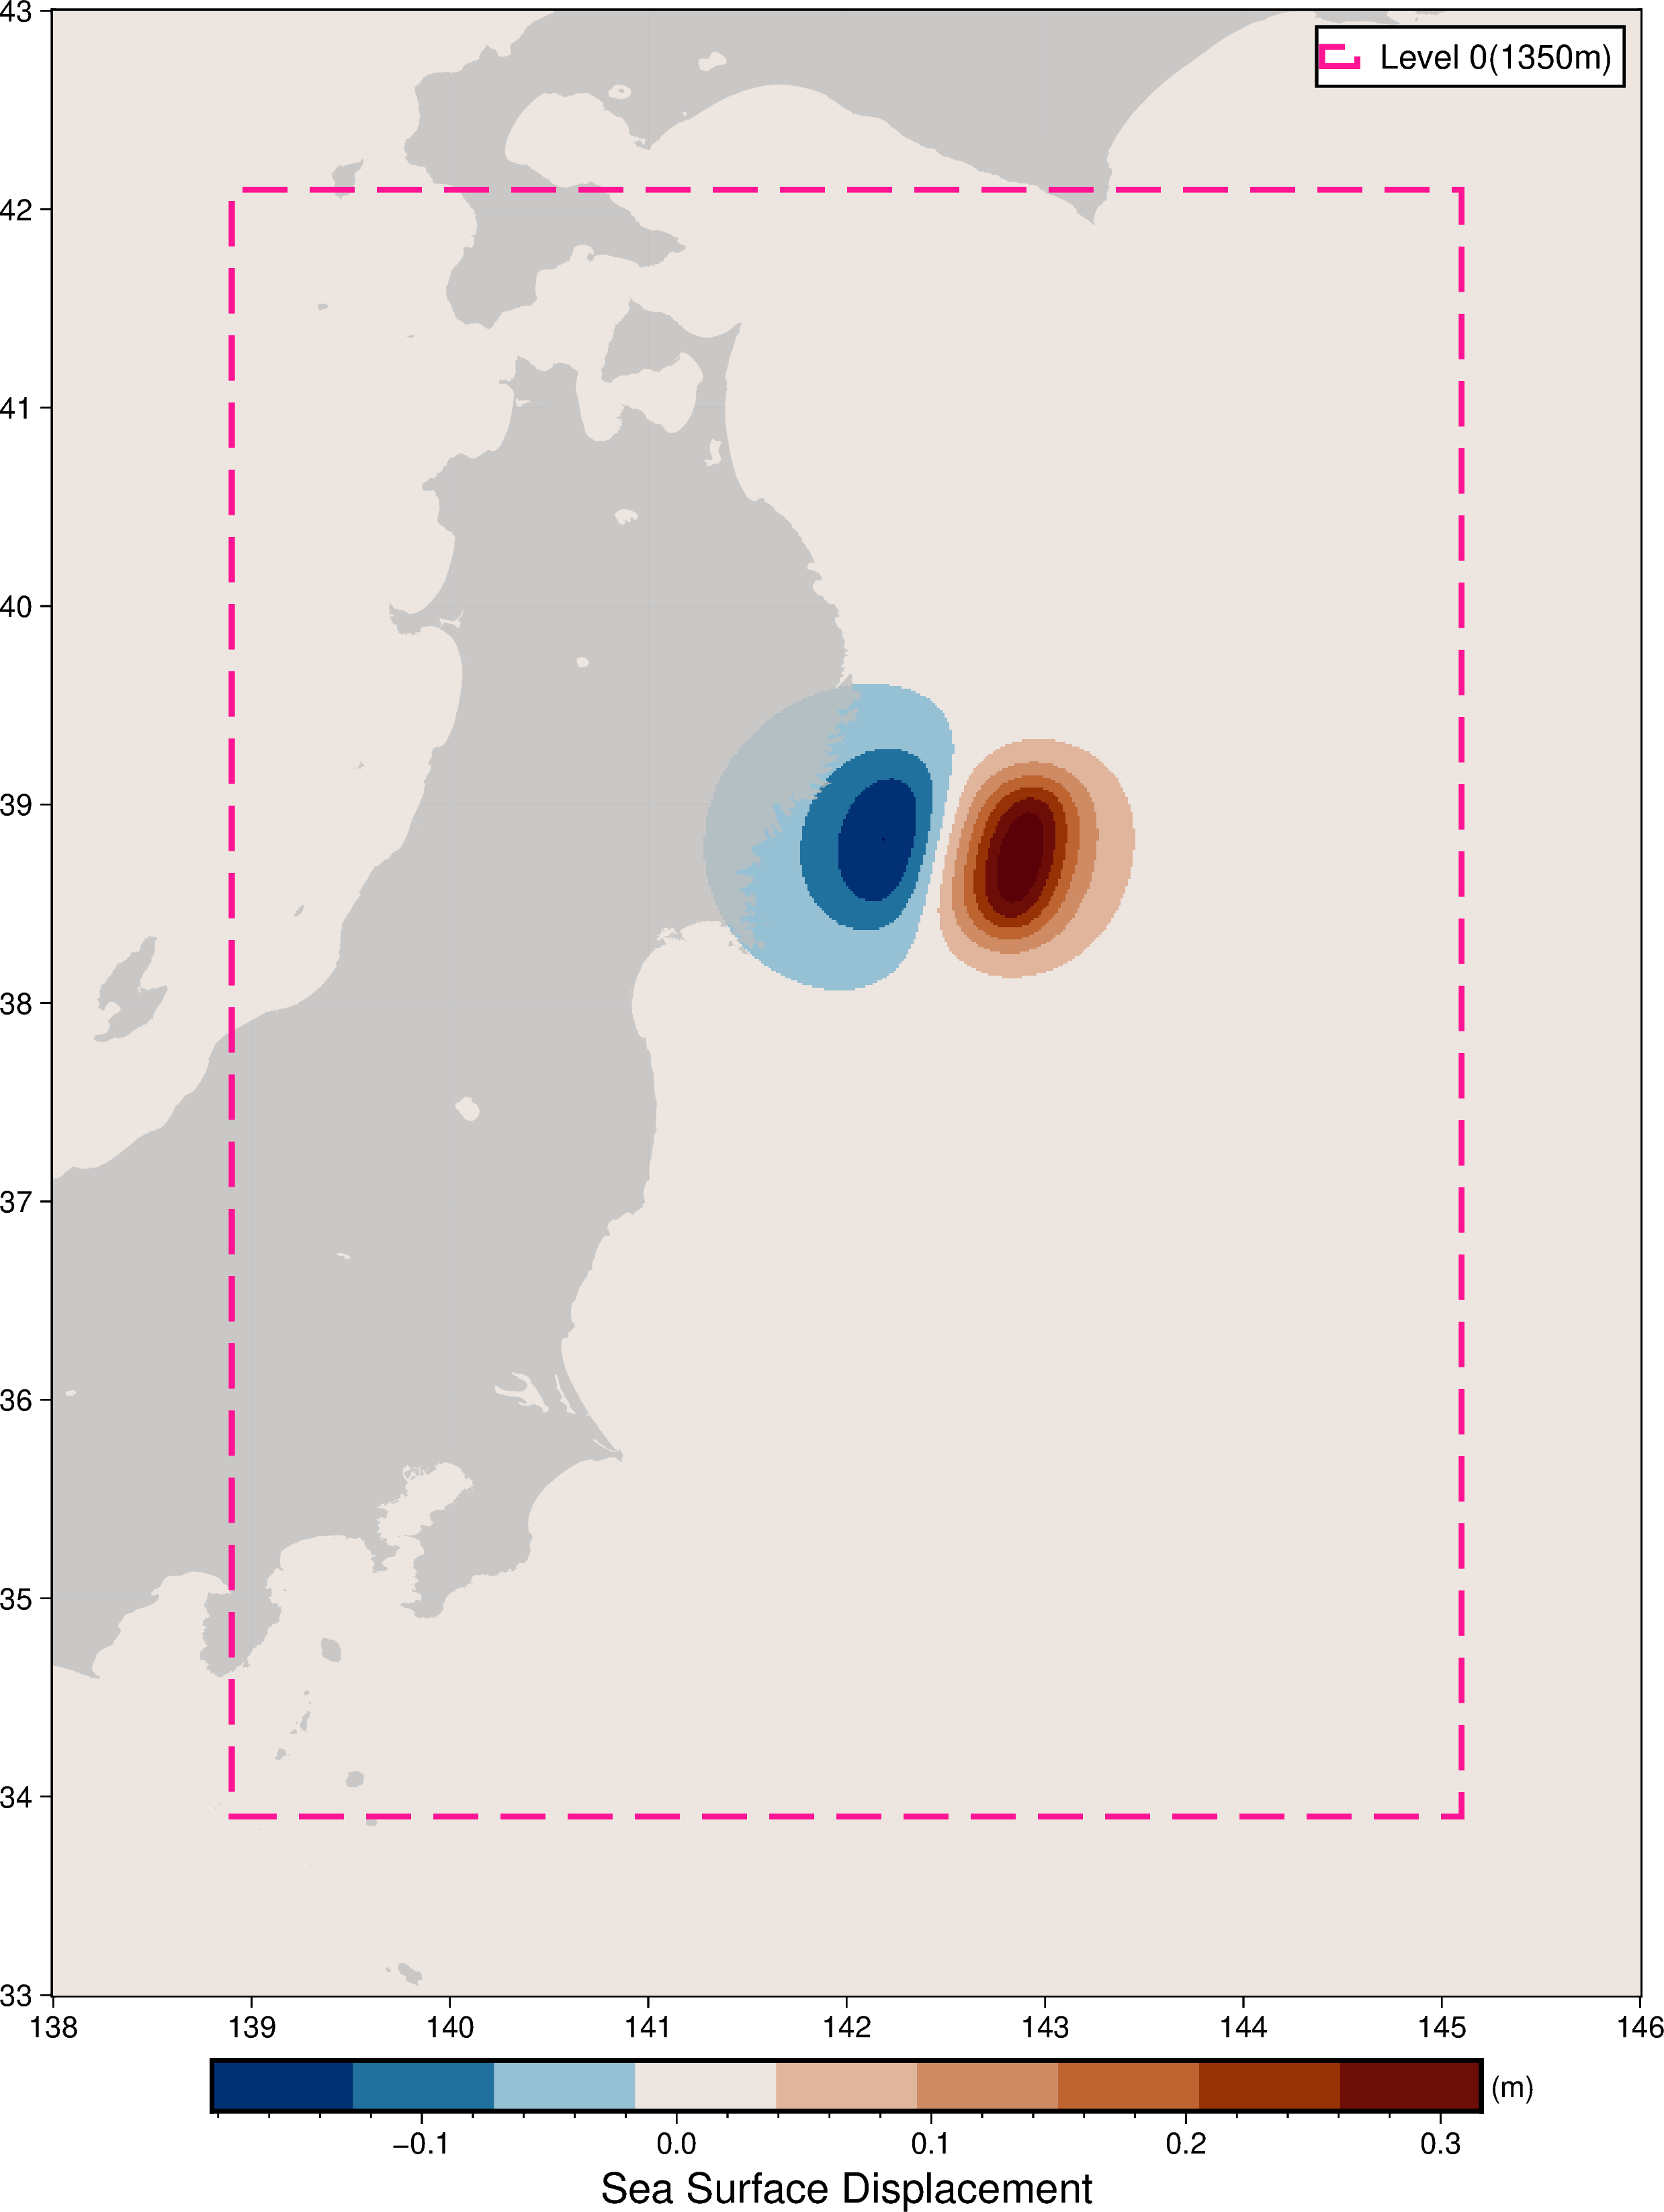

In [12]:
import geopandas as gpd
import numpy as np
import pygmt
import pandas as pd
import os
import rasterio
import xarray as xr

#source
siftpoints = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/GEM/siftpoints.shp")
slabpoints = pd.read_csv("/mnt/data/nragu/Tsunami/Tohoku/gis/GEM/sourceparameters.csv")
path = '/mnt/data/nragu/Tsunami/Tohoku/gis/dtopo_slab/dtopoasc/SL_0035.asc'

#raster processing
grid = rasterio.open(path) #open ascii file
data = grid.read(1) #read 
xlimits = 135,150
ylimits = 45,30
cellsize = 0.01215

# Create coordinates for longitude and latitude
lon = np.linspace(xlimits[0], xlimits[1], data.shape[1])
lat = np.linspace(ylimits[0], ylimits[1], data.shape[0])

# Convert to xarray DataArray
xgrid = xr.DataArray(data, coords=[lat, lon], dims=['lat', 'lon'])
maxval = xgrid.max().values 
minval = xgrid.min().values

#geoclaw model domain extent
domain = gpd.read_file("/mnt/data/nragu/Tsunami/Tohoku/gis/geoclaw/domain.gpkg")
Level0 = domain[domain.Name == '1350']

fig = pygmt.Figure()
pygmt.makecpt(cmap="vik+h0", series=[minval,maxval,(maxval-minval)/10])
fig.basemap(region=[138,146,33,43],projection="x2.5c/2.5c",frame="a") 
fig.grdimage(grid=xgrid,cmap = True)
fig.coast(land= "gray",transparency=25)
fig.plot(data=Level0, pen="2p,deeppink1,-", close=True,label=" Level 0(1350m)")
fig.colorbar(frame=["x+lSea Surface Displacement", "y+l(m)"])#,position="JMR+o0.5c/0c+w10c/0.5c")
pygmt.config(FONT_ANNOT_PRIMARY="12p")
fig.legend()
fig.savefig("_plot/displacement_t1-35.png")
fig.show()
